# FitStyle AI : Recommendation Engine

In [1]:

!pip install -q datasets huggingface_hub pandas numpy scipy pillow matplotlib scikit-learn tqdm open_clip_torch requests

import os
import random
import pickle
import itertools
import json
from io import BytesIO

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
)

from PIL import Image
from datasets import load_dataset
from tqdm.auto import tqdm

import open_clip


CONFIG = {
    "random_seed": 42,
    "image_weight": 0.7,
    "text_weight": 0.3,
    "top_k_candidates": 12,
    "optional_slot_k": 8,      # was 3 - raised so Shoes/Accessory have enough real variety to pick from
    "max_item_reuse": 2,       # NEW - caps how many of the final top-N outfits may reuse the same single item
    "compat_train_frac": 0.70,
    "compat_val_frac": 0.15,
    "compat_test_frac": 0.15,
    "compat_epochs": 120,
    "compat_patience": 12,
    "compat_weight_decay": 3e-4,
    "compat_dropout": 0.2,
    "compat_batch_size": 64,
    "compat_lr": 1e-3,
    "compat_n_pairs_per_split_target": 600,
    "diversity_threshold": None,
    "relevance_weights": {"style": 1/3, "body_shape": 1/3, "occasion": 1/3},
    "outfit_score_weights": {"compatibility": 0.6, "relevance": 0.4},  # compatibility-led, per request
    "min_compat_floor": 0.55,   # NEW - outfits whose weakest pairwise link falls below this are dropped
    "use_ensemble": True,       # NEW - blend CompatibilityNet with the linear model when both are available
    "color_penalty_weight": 0.1,
}

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
torch.manual_seed(CONFIG["random_seed"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Config:", json.dumps(CONFIG, indent=2))


Device: cuda
Config: {
  "random_seed": 42,
  "image_weight": 0.7,
  "text_weight": 0.3,
  "top_k_candidates": 12,
  "optional_slot_k": 8,
  "max_item_reuse": 2,
  "compat_train_frac": 0.7,
  "compat_val_frac": 0.15,
  "compat_test_frac": 0.15,
  "compat_epochs": 120,
  "compat_patience": 12,
  "compat_weight_decay": 0.0003,
  "compat_dropout": 0.2,
  "compat_batch_size": 64,
  "compat_lr": 0.001,
  "compat_n_pairs_per_split_target": 600,
  "diversity_threshold": null,
  "relevance_weights": {
    "style": 0.3333333333333333,
    "body_shape": 0.3333333333333333,
    "occasion": 0.3333333333333333
  },
  "outfit_score_weights": {
    "compatibility": 0.6,
    "relevance": 0.4
  },
  "min_compat_floor": 0.55,
  "use_ensemble": true,
  "color_penalty_weight": 0.1
}


##  Dataset Configuration


In [2]:
DATASET_SOURCE = "huggingface"

HF_DATASET_NAME = "ashraq/fashion-product-images-small"
HF_SPLIT = "train"

CSV_PATH = "your_catalog.csv"
IMAGE_FOLDER = "your_catalog_images"
IMAGE_PATH_COLUMN = "image_path"

COLUMN_MAP = {
    "id": "id",
    "gender": "gender",
    "articleType": "articleType",
    "baseColour": "baseColour",
    "usage": "usage",
    "season": "season",
    "productDisplayName": "productDisplayName",
}


In [3]:
def load_catalog():
    if DATASET_SOURCE == "huggingface":
        raw = load_dataset(HF_DATASET_NAME)[HF_SPLIT].to_pandas()
        raw = raw.rename(columns={v: k for k, v in COLUMN_MAP.items()})
        raw["_image_loader"] = raw["image"].apply(lambda x: lambda im=x: Image.open(BytesIO(im["bytes"])).convert("RGB"))
        return raw

    if DATASET_SOURCE == "csv":
        raw = pd.read_csv(CSV_PATH)
        raw = raw.rename(columns={v: k for k, v in COLUMN_MAP.items()})
        raw["_image_loader"] = raw[IMAGE_PATH_COLUMN].apply(
            lambda p: lambda p=p: Image.open(os.path.join(IMAGE_FOLDER, p)).convert("RGB")
        )
        return raw

    raise ValueError(f"Unknown DATASET_SOURCE: {DATASET_SOURCE}")


def load_image(row):
    return row["_image_loader"]()


df = load_catalog()
print("Loaded catalog rows:", len(df))
print("Columns available:", [c for c in COLUMN_MAP if c in df.columns])


Loaded catalog rows: 44072
Columns available: ['id', 'gender', 'articleType', 'baseColour', 'usage', 'season', 'productDisplayName']


##  Load FashionCLIP



In [4]:
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    "hf-hub:Marqo/marqo-fashionCLIP"
)
tokenizer = open_clip.get_tokenizer("hf-hub:Marqo/marqo-fashionCLIP")
model = model.to(device)
model.eval()  # frozen: inference only, never fine-tuned in this notebook
print("FashionCLIP loaded (pretrained, frozen).")


FashionCLIP loaded (pretrained, frozen).


##   Auto-Fill Missing Catalog Attributes




In [5]:

OCCASION_VIBES = {
    "casual": {
        "vibe": "relaxed everyday casual comfortable easygoing weekend cotton denim sneakers",
        "anti_vibe": "formal black tie gown tuxedo evening wear",
    },
    "formal": {
        "vibe": "formal elegant tailored structured polished sophisticated evening",
        "anti_vibe": "gym sporty athletic beachwear flip flops sweatpants",
    },
    "party": {
        "vibe": "party glamorous statement sequins bold vibrant going out nightlife",
        "anti_vibe": "office conservative modest plain workwear",
    },
    "interview": {
        "vibe": "professional office business conservative modest polished tailored classic understated",
        "anti_vibe": "sexy revealing party clubbing sequined mini",
    },
    "wedding": {
        "vibe": "elegant festive dressy embellished flowing celebratory",
        "anti_vibe": "gym athletic ripped casual streetwear",
    },
}
OCCASION_FALLBACK_KEY = "casual"

CATEGORY_ZERO_SHOT_LABELS = {
    "Top": "a photo of a top, blouse, or t-shirt",
    "Bottom": "a photo of pants, jeans, a skirt, or shorts",
    "Dress": "a photo of a dress",
    "Shoes": "a photo of shoes, heels, flats, or sandals",
    "Outerwear": "a photo of a jacket, coat, blazer, or sweater",
    "Accessory": "a photo of a bag, belt, watch, sunglasses, or jewelry",
}
COLOR_ZERO_SHOT_LABELS = [
    "black", "white", "red", "blue", "green", "yellow", "pink",
    "purple", "orange", "brown", "grey", "beige", "navy", "multicolor",
]
SEASON_ZERO_SHOT_LABELS = ["summer", "winter", "fall", "spring"]

def zero_shot_classify(image_embeds, label_to_text):
    keys = list(label_to_text.keys())
    tokens = tokenizer(list(label_to_text.values())).to(device)
    with torch.no_grad():
        text_embeds = model.encode_text(tokens, normalize=True).cpu()
    sims = image_embeds @ text_embeds.T
    best_idx = sims.argmax(dim=1).numpy()
    return [keys[i] for i in best_idx]

def compute_image_embeddings(products_df, batch_size=32):
    all_embeds = []
    for start in tqdm(range(0, len(products_df), batch_size), desc="Embedding images for auto-fill"):
        batch = products_df.iloc[start:start + batch_size]
        images = []
        for _, row in batch.iterrows():
            try:
                images.append(load_image(row))
            except Exception:
                images.append(Image.new("RGB", (224, 224), color=0))
        inputs = torch.stack([preprocess_val(img) for img in images]).to(device)
        with torch.no_grad():
            feats = model.encode_image(inputs, normalize=True)
        all_embeds.append(feats.cpu())
    return torch.cat(all_embeds, dim=0)


missing_fields = [f for f in ["articleType", "baseColour", "usage", "season"] if f not in df.columns]

ATTRIBUTE_PROVENANCE = {
    "articleType": "catalog" if "articleType" in df.columns else "inferred",
    "baseColour": "catalog" if "baseColour" in df.columns else "inferred",
    "usage": "catalog" if "usage" in df.columns else "inferred",
    "season": "catalog" if "season" in df.columns else "inferred",
}

if missing_fields:
    print("Missing from your data, will predict from images:", missing_fields)
    raw_image_embeds = compute_image_embeddings(df)

    if "articleType" not in df.columns:
        df["garment_category"] = zero_shot_classify(raw_image_embeds, CATEGORY_ZERO_SHOT_LABELS)
    if "baseColour" not in df.columns:
        df["baseColour"] = zero_shot_classify(raw_image_embeds, {c: f"a {c} colored garment" for c in COLOR_ZERO_SHOT_LABELS})
    if "usage" not in df.columns:
        df["usage"] = zero_shot_classify(raw_image_embeds, {k: v["vibe"] for k, v in OCCASION_VIBES.items()})
    if "season" not in df.columns:
        df["season"] = zero_shot_classify(raw_image_embeds, {s: f"a {s} outfit" for s in SEASON_ZERO_SHOT_LABELS})
else:
    print("All expected columns are present — no attribute prediction needed.")

if "id" not in df.columns:
    df["id"] = range(len(df))
if "productDisplayName" not in df.columns:
    df["productDisplayName"] = ""

print("Attribute provenance (catalog = real merchant value, inferred = zero-shot predicted):")
print(ATTRIBUTE_PROVENANCE)
print("Catalog ready. Inferred attributes are heuristic-quality — prefer real merchant tags where available.")
df.head(3)


All expected columns are present — no attribute prediction needed.
Attribute provenance (catalog = real merchant value, inferred = zero-shot predicted):
{'articleType': 'catalog', 'baseColour': 'catalog', 'usage': 'catalog', 'season': 'catalog'}
Catalog ready. Inferred attributes are heuristic-quality — prefer real merchant tags where available.


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image,_image_loader
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,<function load_catalog.<locals>.<lambda>.<loca...
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,<function load_catalog.<locals>.<lambda>.<loca...
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,<function load_catalog.<locals>.<lambda>.<loca...


##   Catalog Validation and Cleaning




In [6]:
cleaning_report = {"duplicate_ids_dropped": 0, "unreadable_images_in_sample": 0, "missing_critical_fields_dropped": 0}

before = len(df)
df = df.drop_duplicates(subset="id", keep="first")
cleaning_report["duplicate_ids_dropped"] = before - len(df)

critical_fields = ["id", "garment_category" if "garment_category" in df.columns else "articleType"]
before = len(df)
df = df.dropna(subset=[c for c in critical_fields if c in df.columns])
cleaning_report["missing_critical_fields_dropped"] = before - len(df)


sample_check = df.sample(min(30, len(df)), random_state=CONFIG["random_seed"])
unreadable = 0
for _, row in sample_check.iterrows():
    try:
        load_image(row)
    except Exception:
        unreadable += 1
cleaning_report["unreadable_images_in_sample"] = unreadable  # count from the sample, not the full catalog — see note below
if unreadable > 0:
    print(f"WARNING: {unreadable}/{len(sample_check)} sampled images failed to load. "
          f"Your image source or paths may be broken — recommendations will silently use a blank "
          f"placeholder image for any product whose image fails to load later.")

if len(df) == 0:
    raise ValueError(
        "Catalog is empty after cleaning. Check DATASET_SOURCE / COLUMN_MAP in Section 1 — "
        "most likely a column name mismatch caused everything to be dropped."
    )


print("\nColumn completeness (share of non-empty values):")
for col in ["articleType", "baseColour", "usage", "season", "productDisplayName"]:
    if col in df.columns:
        non_empty = df[col].apply(lambda v: str(v).strip() not in ("", "nan", "None")).mean()
        print(f"  {col:<20} {non_empty:.1%} non-empty")

print("\nCleaning report:", cleaning_report)
print("Catalog rows after cleaning:", len(df))



Column completeness (share of non-empty values):
  articleType          100.0% non-empty
  baseColour           100.0% non-empty
  usage                100.0% non-empty
  season               100.0% non-empty
  productDisplayName   100.0% non-empty

Cleaning report: {'duplicate_ids_dropped': 0, 'unreadable_images_in_sample': 0, 'missing_critical_fields_dropped': 0}
Catalog rows after cleaning: 44072


## Build the Recommendation Catalog


In [7]:
working = df[df["gender"].str.lower() == "women"].copy() if "gender" in df.columns else df.copy()

allowed_types = [
    "Tops", "Tshirts", "Shirts",
    "Jeans", "Trousers", "Skirts", "Shorts",
    "Dresses",
    "Heels", "Flats", "Casual Shoes", "Sandals", "Sports Shoes", "Formal Shoes", "Flip Flops",
    "Jackets", "Sweatshirts", "Sweaters", "Blazers",
    "Handbags", "Belts", "Watches", "Sunglasses", "Jewellery", "Bangle", "Necklace and Chains",
    "Earrings", "Scarves", "Backpacks", "Clutches", "Wallets",
]

def map_garment_category(article_type):
    if article_type in ["Tops", "Tshirts", "Shirts"]:
        return "Top"
    if article_type in ["Jeans", "Trousers", "Skirts", "Shorts"]:
        return "Bottom"
    if article_type == "Dresses":
        return "Dress"
    if article_type in ["Heels", "Flats", "Casual Shoes", "Sandals", "Sports Shoes", "Formal Shoes", "Flip Flops"]:
        return "Shoes"
    if article_type in ["Jackets", "Sweatshirts", "Sweaters", "Blazers"]:
        return "Outerwear"
    if article_type in ["Handbags", "Belts", "Watches", "Sunglasses", "Jewellery", "Bangle",
                         "Necklace and Chains", "Earrings", "Scarves", "Backpacks", "Clutches", "Wallets"]:
        return "Accessory"
    return "Other"

if "articleType" in working.columns:
    catalog = working[working["articleType"].isin(allowed_types)].copy()
    catalog["garment_category"] = catalog["articleType"].apply(map_garment_category)
else:
    catalog = working[working["garment_category"].isin(list(CATEGORY_ZERO_SHOT_LABELS.keys()))].copy()
    catalog["articleType"] = catalog["garment_category"]

if len(catalog) == 0:
    raise ValueError("No products matched a supported category. Check articleType/garment_category values.")

print("Catalog size:", len(catalog))
catalog["garment_category"].value_counts()


Catalog size: 11513


,count
garment_category,
Accessory,4683
Top,2939
Shoes,2799
Bottom,497
Dress,390
Outerwear,205


## Product Sizes


In [8]:
POSSIBLE_SIZES = [["S", "M", "L"], ["S", "M", "L", "XL"], ["M", "L"], ["S", "M"], ["M"]]

def attach_mock_sizes(catalog_df):
    catalog_df = catalog_df.copy()
    catalog_df["available_sizes"] = [random.choice(POSSIBLE_SIZES) for _ in range(len(catalog_df))]
    return catalog_df

catalog = attach_mock_sizes(catalog)
catalog[["id", "articleType", "available_sizes"]].head(5)


,id,articleType,available_sizes
2,59263,Watches,"[S, M, L]"
7,26960,Shirts,"[S, M, L]"
11,48123,Belts,"[M, L]"
13,47957,Handbags,"[S, M, L, XL]"
19,47359,Handbags,"[S, M, L, XL]"


## Sample User Profile


In [9]:
SAMPLE_USERS = [
    {"size": "M", "body_shape": "pear",             "occasion": "Casual", "season": "Summer", "style": "casual"},
    {"size": "S", "body_shape": "hourglass",         "occasion": "Formal", "season": "Winter", "style": "elegant"},
    {"size": "L", "body_shape": "apple",             "occasion": "Party",  "season": "Summer", "style": "chic"},
    {"size": "M", "body_shape": "rectangle",         "occasion": "Casual", "season": "Fall",   "style": "streetwear"},
    {"size": "S", "body_shape": "inverted_triangle", "occasion": "Casual", "season": "Summer", "style": "casual"},
]

def get_sample_user(index=0):
    return SAMPLE_USERS[index % len(SAMPLE_USERS)]

user_profile = get_sample_user(index=0)
user_profile


{'size': 'M',
 'body_shape': 'pear',
 'occasion': 'Casual',
 'season': 'Summer',
 'style': 'casual'}

## Hard Filtering


In [10]:
def _norm(s):
    return str(s).strip().lower()

def filter_products(catalog_df, user):
    filtered = catalog_df.copy()
    filtered = filtered[filtered["available_sizes"].apply(lambda sizes: user["size"] in sizes)]
    filtered = filtered[filtered["season"].apply(_norm) == _norm(user["season"])]
    filtered = filtered[filtered["usage"].apply(_norm) == _norm(user["occasion"])]
    return filtered.reset_index(drop=True)

eligible_products = filter_products(catalog, user_profile)
eligible_products = eligible_products.reset_index(drop=True)

if len(eligible_products) == 0:
    raise ValueError(
        "No products survived the size/season/occasion filter for this user profile. "
        "Either the catalog is too small/narrow for this profile, or season/usage values "
        "don't match what the user profile expects — check spelling/casing."
    )

print("Eligible products after size/season/occasion filter:", len(eligible_products))
eligible_products["garment_category"].value_counts()


Eligible products after size/season/occasion filter: 4762


,count
garment_category,
Top,1843
Accessory,1820
Shoes,529
Bottom,274
Dress,257
Outerwear,39


## Generate Product Embeddings


In [11]:
IMAGE_WEIGHT = CONFIG["image_weight"]
TEXT_WEIGHT = CONFIG["text_weight"]

def build_text_description(row):
    return (
        f"{row.get('baseColour', '')} {row.get('articleType', '')} "
        f"for {row.get('usage', '')}, {row.get('productDisplayName', '')}"
    ).strip()

def generate_blended_embeddings(products_df, batch_size=32):
    all_embeddings, all_image_only = [], []
    for start in tqdm(range(0, len(products_df), batch_size), desc="Embedding products"):
        batch = products_df.iloc[start:start + batch_size]
        batch_images, batch_texts = [], []
        for _, product in batch.iterrows():
            try:
                img = load_image(product)
            except Exception:
                img = Image.new("RGB", (224, 224), color=0)
            batch_images.append(img)
            batch_texts.append(build_text_description(product))

        image_inputs = torch.stack([preprocess_val(img) for img in batch_images]).to(device)
        text_inputs = tokenizer(batch_texts).to(device)

        with torch.no_grad():
            image_features = model.encode_image(image_inputs, normalize=True)
            text_features = model.encode_text(text_inputs, normalize=True)
            blended = IMAGE_WEIGHT * image_features + TEXT_WEIGHT * text_features
            blended = blended / blended.norm(dim=-1, keepdim=True)

        all_embeddings.append(blended.cpu())
        all_image_only.append(image_features.cpu())
    return torch.cat(all_embeddings, dim=0), torch.cat(all_image_only, dim=0)


# ---------------------------------------------------------------------------
# Multi-profile fix: embed the FULL `catalog`, not `eligible_products` (which
# is already filtered down to ONE demo user's size/season/occasion). Product
# embeddings depend only on the product's own image/text, never on which
# user is asking, so they are computed once for every product that could
# EVER be recommended to ANY profile.
# ---------------------------------------------------------------------------
product_embeddings, product_image_embeddings = generate_blended_embeddings(catalog)

embedding_index = catalog[["id", "articleType", "garment_category"]].copy()
embedding_index["embedding_index"] = range(len(embedding_index))
id_to_embedding_index = dict(zip(embedding_index["id"], embedding_index["embedding_index"]))

def get_embedding(product_id):
    return product_embeddings[id_to_embedding_index[product_id]]

def get_image_embedding(product_id):
    return product_image_embeddings[id_to_embedding_index[product_id]]

# The rest of this notebook (below) was written assuming "product_embeddings"
# is the SAME LENGTH AND ROW ORDER as "eligible_products" (true only when
# embeddings were generated from eligible_products directly). Now that
# embeddings cover the full catalog, we rebuild that same alignment as an
# explicit SUBSET, so every existing cell below keeps working unchanged.
eligible_embeddings = torch.stack([get_embedding(pid) for pid in eligible_products["id"]])
eligible_image_embeddings = torch.stack([get_image_embedding(pid) for pid in eligible_products["id"]])

print("Embeddings shape (full catalog):", product_embeddings.shape)
print("Embeddings shape (this profile's eligible subset):", eligible_embeddings.shape)


Embedding products:   0%|          | 0/360 [00:00<?, ?it/s]

Embeddings shape (full catalog): torch.Size([11513, 512])
Embeddings shape (this profile's eligible subset): torch.Size([4762, 512])


## Body Shape Scoring




In [12]:
BODY_SHAPE_RULES = {
    "pear": {
        "prefer": ["an a-line skirt or dress", "a wrap top or dress", "a flared silhouette", "a boat neck or off-shoulder top"],
        "avoid": ["a bodycon fit", "a pencil skirt", "skinny tapered bottoms"],
    },
    "hourglass": {
        "prefer": ["a fitted, belted silhouette", "a wrap dress", "a high-waisted cut", "a v-neck top"],
        "avoid": ["an oversized boxy fit", "a shapeless silhouette"],
    },
    "apple": {
        "prefer": ["an empire waist", "an a-line silhouette", "a flowy tunic", "a v-neck top"],
        "avoid": ["a bodycon fit", "a cropped tight top"],
    },
    "rectangle": {
        "prefer": ["a peplum top", "a belted waist", "a ruffled or layered design", "a flared silhouette"],
        "avoid": ["a straight, shapeless cut"],
    },
    "inverted_triangle": {
        "prefer": ["a flared or wide-leg bottom", "an a-line silhouette", "a bootcut fit"],
        "avoid": ["a boat neck top", "puff sleeves", "shoulder pads"],
    },
}

def get_body_shape_attribute_vectors(body_shape):
    rules = BODY_SHAPE_RULES.get(body_shape)
    if rules is None:
        return None, None
    prefer_tokens = tokenizer(rules["prefer"]).to(device)
    avoid_tokens = tokenizer(rules["avoid"]).to(device)
    with torch.no_grad():
        prefer_vecs = model.encode_text(prefer_tokens, normalize=True).cpu()
        avoid_vecs = model.encode_text(avoid_tokens, normalize=True).cpu()
    return prefer_vecs, avoid_vecs

def body_shape_scores(image_embeddings, body_shape):
    prefer_vecs, avoid_vecs = get_body_shape_attribute_vectors(body_shape)
    if prefer_vecs is None:
        return np.zeros(len(image_embeddings))
    prefer_score = (image_embeddings @ prefer_vecs.T).max(dim=1).values
    avoid_score = (image_embeddings @ avoid_vecs.T).max(dim=1).values
    return (prefer_score - avoid_score).numpy()

eligible_products["body_shape_score"] = body_shape_scores(eligible_image_embeddings, user_profile["body_shape"])
eligible_products["body_shape_score"].describe()


,body_shape_score
count,4762.000000
mean,0.026805
std,0.041832
min,-0.136355
25%,0.004903
50%,0.029978
75%,0.052878
max,0.174377


##  Occasion Matching




In [13]:
LAMBDA_OCCASION = 2.0

def get_occasion_vibe_vectors(occasion):
    key = _norm(occasion)
    vibes = OCCASION_VIBES.get(key, OCCASION_VIBES[OCCASION_FALLBACK_KEY])
    tokens = tokenizer([vibes["vibe"], vibes["anti_vibe"]]).to(device)
    with torch.no_grad():
        embeds = model.encode_text(tokens, normalize=True)
    return embeds[0].cpu(), embeds[1].cpu()

def occasion_affinity_scores(embeddings, occasion):
    vibe_vec, anti_vibe_vec = get_occasion_vibe_vectors(occasion)
    cos_vibe = embeddings @ vibe_vec
    cos_anti = embeddings @ anti_vibe_vec
    penalty = torch.clamp(cos_anti - cos_vibe, min=0.0) * LAMBDA_OCCASION
    return (cos_vibe - penalty).numpy()

eligible_products["occasion_affinity"] = occasion_affinity_scores(eligible_embeddings, user_profile["occasion"])
eligible_products[["articleType", "occasion_affinity"]].sort_values("occasion_affinity", ascending=False).head(5)


,articleType,occasion_affinity
4478,Casual Shoes,0.408421
2935,Casual Shoes,0.404095
3961,Casual Shoes,0.403671
1732,Casual Shoes,0.399149
1376,Casual Shoes,0.388080


##  Combined Relevance Score




In [14]:
W_STYLE = CONFIG["relevance_weights"]["style"]
W_BODY_SHAPE = CONFIG["relevance_weights"]["body_shape"]
W_OCCASION = CONFIG["relevance_weights"]["occasion"]

user_text = f"A {user_profile['style']} {user_profile['season'].lower()} outfit"
text_tokens = tokenizer([user_text]).to(device)
with torch.no_grad():
    user_embedding = model.encode_text(text_tokens, normalize=True).cpu()

eligible_products["style_similarity"] = (eligible_embeddings @ user_embedding.T).squeeze(1).numpy()

def _minmax(series):
    lo, hi = series.min(), series.max()
    if hi - lo < 1e-8:
        return series * 0.0
    return (series - lo) / (hi - lo)

def compute_relevance_score(df_, w_style, w_body, w_occasion):
    return (
        w_style * _minmax(df_["style_similarity"])
        + w_body * _minmax(df_["body_shape_score"])
        + w_occasion * _minmax(df_["occasion_affinity"])
    )

eligible_products["relevance_score"] = compute_relevance_score(eligible_products, W_STYLE, W_BODY_SHAPE, W_OCCASION)

TOP_K = CONFIG["top_k_candidates"]
categories_present = sorted(eligible_products["garment_category"].unique().tolist())

def build_candidate_pools(df_, top_k=TOP_K):
    pools = {}
    # Multi-profile fix: derive categories from df_ ITSELF, not the stale
    # global `categories_present` computed for whichever profile ran first -
    # otherwise a different profile's categories would be silently ignored
    # (or a category present for THIS profile but absent from the first run
    # would raise a KeyError).
    for category in sorted(df_["garment_category"].unique().tolist()):
        if category == "Other":
            continue
        pools[category] = (
            df_[df_["garment_category"] == category]
            .sort_values("relevance_score", ascending=False)
            .head(top_k)
            .reset_index(drop=True)
        )
    return pools

candidate_products = build_candidate_pools(eligible_products)
for category, pool in candidate_products.items():
    print(category, ":", len(pool), "candidates")


Accessory : 12 candidates
Bottom : 12 candidates
Dress : 12 candidates
Outerwear : 12 candidates
Shoes : 12 candidates
Top : 12 candidates


## Relevance Weight Sensitivity Analysis




In [15]:
WEIGHT_CONFIGS = {
    "Equal (current default)":  {"style": 1/3, "body_shape": 1/3, "occasion": 1/3},
    "Style-led":                {"style": 0.40, "body_shape": 0.30, "occasion": 0.30},
    "Body-led":                 {"style": 0.30, "body_shape": 0.40, "occasion": 0.30},
    "Occasion-led":             {"style": 0.30, "body_shape": 0.30, "occasion": 0.40},
}

def top_k_ids(df_, w, k=10):
    scored = compute_relevance_score(df_, w["style"], w["body_shape"], w["occasion"])
    return set(df_.assign(_s=scored).sort_values("_s", ascending=False).head(k)["id"])

baseline_ids = top_k_ids(eligible_products, WEIGHT_CONFIGS["Equal (current default)"])

print(f"{'Config':<26} {'Overlap with equal (top-10)':<30} {'Mean relevance (top-10)'}")
for name, w in WEIGHT_CONFIGS.items():
    ids = top_k_ids(eligible_products, w)
    overlap = len(ids & baseline_ids) / 10
    scored = compute_relevance_score(eligible_products, w["style"], w["body_shape"], w["occasion"])
    mean_top10 = eligible_products.assign(_s=scored).sort_values("_s", ascending=False).head(10)["_s"].mean()
    print(f"{name:<26} {overlap:<30.0%} {mean_top10:.3f}")

print(
    "\nInterpretation: this shows HOW MUCH the ranking changes under each weighting, not which one is "
    "'correct' — there is no ground truth to validate against. Equal weighting is kept as the default "
    "because it makes no unjustified assumption about which signal matters more to this particular user; "
    "it is a documented heuristic, not an optimized result.\n\n"
    "# --- If real preference labels ever exist, replace this cell with, e.g.: -----\n"
    "# best_w, best_metric = None, -1\n"
    "# for w in candidate_weight_grid:                      # grid/random search\n"
    "#     metric = evaluate_against_validation_labels(w, val_preference_labels)\n"
    "#     if metric > best_metric: best_w, best_metric = w, metric\n"
    "# # then evaluate best_w exactly once on the untouched test split.\n"
)

SELECTED_WEIGHTS = WEIGHT_CONFIGS["Equal (current default)"]


Config                     Overlap with equal (top-10)    Mean relevance (top-10)
Equal (current default)    100%                           0.843
Style-led                  80%                            0.846
Body-led                   90%                            0.845
Occasion-led               100%                           0.839

Interpretation: this shows HOW MUCH the ranking changes under each weighting, not which one is 'correct' — there is no ground truth to validate against. Equal weighting is kept as the default because it makes no unjustified assumption about which signal matters more to this particular user; it is a documented heuristic, not an optimized result.

# --- If real preference labels ever exist, replace this cell with, e.g.: -----
# best_w, best_metric = None, -1
# for w in candidate_weight_grid:                      # grid/random search
#     metric = evaluate_against_validation_labels(w, val_preference_labels)
#     if metric > best_metric: best_w, best_metr

## Product-Level Train / Validation / Test Split




In [16]:
def product_level_split(df_, train_frac, val_frac, test_frac, seed):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    ids = df_["id"].drop_duplicates().sample(frac=1.0, random_state=seed).tolist()
    n = len(ids)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_ids = set(ids[:n_train])
    val_ids = set(ids[n_train:n_train + n_val])
    test_ids = set(ids[n_train + n_val:])
    return train_ids, val_ids, test_ids

# Multi-profile fix: split the FULL catalog, not the one-profile-filtered
# eligible_products, so CompatibilityNet learns from every category/color
# combination in the catalog, not just what survives one demo profile's
# filter.
train_ids, val_ids, test_ids = product_level_split(
    catalog,
    CONFIG["compat_train_frac"], CONFIG["compat_val_frac"], CONFIG["compat_test_frac"],
    CONFIG["random_seed"],
)

products_train = catalog[catalog["id"].isin(train_ids)].reset_index(drop=True)
products_val = catalog[catalog["id"].isin(val_ids)].reset_index(drop=True)
products_test = catalog[catalog["id"].isin(test_ids)].reset_index(drop=True)

print(f"Products — train: {len(products_train)}  val: {len(products_val)}  test: {len(products_test)}")
assert train_ids.isdisjoint(val_ids) and train_ids.isdisjoint(test_ids) and val_ids.isdisjoint(test_ids), "Split leaked!"
print("No product appears in more than one split (verified).")


Products — train: 8059  val: 1726  test: 1728
No product appears in more than one split (verified).


## Data Leakage Audit



In [17]:

assert train_ids.isdisjoint(val_ids) and train_ids.isdisjoint(test_ids) and val_ids.isdisjoint(test_ids)

def pair_products_within_split(pairs, allowed_ids):
    allowed = set(str(i) for i in allowed_ids)
    return all(str(a) in allowed and str(b) in allowed for a, b, _ in pairs)


print("Leakage audit checks defined. Pair-level verification runs immediately after pair generation in Section 16.")


Leakage audit checks defined. Pair-level verification runs immediately after pair generation in Section 16.


## CompatibilityNet: Data-Driven Pair Generation



In [18]:
NEUTRAL_COLORS_SET = {"black", "white", "grey", "gray", "navy", "beige", "brown", "tan", "cream"}
COLOR_CENTROID_MIN_SAMPLES = 3


def compute_color_centroids(products_df, min_samples=COLOR_CENTROID_MIN_SAMPLES):

    centroids = {}
    colors = products_df["baseColour"].astype(str).str.lower()
    for color in colors.unique():
        ids = products_df.loc[colors == color, "id"]
        if len(ids) < min_samples:
            continue
        embs = torch.stack([get_embedding(pid) for pid in ids])
        centroid = embs.mean(dim=0)
        centroids[color] = centroid / centroid.norm()
    return centroids


def color_relationship_score(color_a, color_b, centroids):
    a, b = str(color_a).lower(), str(color_b).lower()
    if a == b:
        return 1.0
    if a in NEUTRAL_COLORS_SET or b in NEUTRAL_COLORS_SET:
        return 1.0
    if a in centroids and b in centroids:
        return float((centroids[a] @ centroids[b]).item())
    return None


def sample_cross_category_pair(products_df, categories, rng):
    c1, c2 = rng.sample(categories, 2)
    pool_a = products_df[products_df["garment_category"] == c1]
    pool_b = products_df[products_df["garment_category"] == c2]
    if len(pool_a) == 0 or len(pool_b) == 0:
        return None
    a = pool_a.sample(1, random_state=rng.randint(0, 10_000)).iloc[0]
    b = pool_b.sample(1, random_state=rng.randint(0, 10_000)).iloc[0]
    return a, b


def build_pairs_for_split(products_df, n_pairs_target, seed):
    rng = random.Random(seed)
    categories = products_df["garment_category"].unique().tolist()
    if len(categories) < 2 or len(products_df) < 4:
        return [], {}

    color_centroids = compute_color_centroids(products_df)

    candidates, seen = [], set()
    attempts, max_attempts = 0, n_pairs_target * 40
    while len(candidates) < n_pairs_target * 3 and attempts < max_attempts:
        attempts += 1
        pair = sample_cross_category_pair(products_df, categories, rng)
        if pair is None:
            continue
        a, b = pair
        key = tuple(sorted([str(a["id"]), str(b["id"])]))
        if key in seen:
            continue
        seen.add(key)
        color_score = color_relationship_score(a["baseColour"], b["baseColour"], color_centroids)
        if color_score is None:
            continue
        emb_sim = float((get_embedding(a["id"]) @ get_embedding(b["id"])).item())
        candidates.append({
            "a": a["id"], "b": b["id"], "color_score": color_score, "emb_sim": emb_sim,
            "cat_pair": tuple(sorted([a["garment_category"], b["garment_category"]])),
        })

    if not candidates:
        return [], {}

    scores = sorted(c["color_score"] for c in candidates)
    lo, hi = scores[0], scores[-1]
    median_score = scores[len(scores) // 2]


    soft_pairs = []
    for c in candidates[:n_pairs_target]:
        rescaled = (c["color_score"] - lo) / max(1e-6, (hi - lo))
        soft_pairs.append((c["a"], c["b"], float(np.clip(rescaled, 0.0, 1.0))))


    hard_neg_pool = sorted(
        [c for c in candidates if c["color_score"] < median_score],
        key=lambda c: -c["emb_sim"],
    )
    n_hard = min(len(hard_neg_pool), max(1, n_pairs_target // 2))
    hard_negatives = [(c["a"], c["b"], 0.0) for c in hard_neg_pool[:n_hard]]


    same_cat_negatives = []
    attempts = 0
    target_same_cat = max(1, int(len(soft_pairs) * 0.08))
    while len(same_cat_negatives) < target_same_cat and attempts < max_attempts:
        attempts += 1
        cat = rng.choice(categories)
        pool = products_df[products_df["garment_category"] == cat]
        if len(pool) < 2:
            continue
        rows = pool.sample(2, random_state=rng.randint(0, 10_000))
        same_cat_negatives.append((rows.iloc[0]["id"], rows.iloc[1]["id"], 0.0))

    pairs = soft_pairs + hard_negatives + same_cat_negatives
    rng.shuffle(pairs)

    diagnostics = {
        "n_candidates_considered": len(candidates),
        "color_score_range": (lo, hi),
        "color_score_median": median_score,
        "n_soft_pairs": len(soft_pairs),
        "n_hard_negatives": len(hard_negatives),
        "n_same_category_negatives": len(same_cat_negatives),
    }
    return pairs, diagnostics


target_n = CONFIG["compat_n_pairs_per_split_target"]
train_pairs, train_pair_diag = build_pairs_for_split(products_train, target_n, seed=CONFIG["random_seed"])
val_pairs, val_pair_diag = build_pairs_for_split(products_val, max(50, target_n // 4), seed=CONFIG["random_seed"] + 1)
test_pairs, test_pair_diag = build_pairs_for_split(products_test, max(50, target_n // 4), seed=CONFIG["random_seed"] + 2)

assert pair_products_within_split(train_pairs, train_ids), "Train pairs reference out-of-split products!"
assert pair_products_within_split(val_pairs, val_ids), "Val pairs reference out-of-split products!"
assert pair_products_within_split(test_pairs, test_ids), "Test pairs reference out-of-split products!"
print("Pair-level leakage check passed: every pair's products belong to their own split.")


for name, pairs in [("train", train_pairs), ("val", val_pairs), ("test", test_pairs)]:
    n_pos = sum(1 for *_, lbl in pairs if lbl >= 0.5)
    ratio = n_pos / len(pairs) if pairs else float("nan")
    print(f"{name}: {len(pairs)} pairs ({n_pos} with label >= 0.5 / {len(pairs) - n_pos} below, class ratio {ratio:.1%})")

print(f"\nUnique products — train: {products_train['id'].nunique()}, val: {products_val['id'].nunique()}, test: {products_test['id'].nunique()}")
print("(Unique category-pair types and their label distribution are reported in Section 17 below.)")


MIN_PAIRS_FOR_NEURAL_TRAINING = 60
SMALL_CATALOG_FALLBACK_ACTIVE = len(train_pairs) < MIN_PAIRS_FOR_NEURAL_TRAINING or len(val_pairs) < 15

if SMALL_CATALOG_FALLBACK_ACTIVE:
    print(
        f"\nFALLBACK ACTIVE: only {len(train_pairs)} train / {len(val_pairs)} val pairs — too few to "
        f"train CompatibilityNet reliably (threshold: {MIN_PAIRS_FOR_NEURAL_TRAINING} train / 15 val). "
        "Section 19 will skip neural training and use the proxy signal formula directly as the "
        "compatibility score instead. This is reported explicitly in the output JSON and audit table, "
        "not silently substituted."
    )
elif len(train_pairs) < 100 or len(val_pairs) < 20 or len(test_pairs) < 20:
    print(
        "WARNING: this catalog (after size/season/occasion filtering) is small relative to what a "
        "reliable compatibility model needs. Treat CompatibilityNet's test metrics below as indicative, "
        "not as a rigorous estimate of real-world generalization — see the Limitations section."
    )


Pair-level leakage check passed: every pair's products belong to their own split.
train: 948 pairs (503 with label >= 0.5 / 445 below, class ratio 53.1%)
val: 237 pairs (126 with label >= 0.5 / 111 below, class ratio 53.2%)
test: 237 pairs (115 with label >= 0.5 / 122 below, class ratio 48.5%)

Unique products — train: 8059, val: 1726, test: 1728
(Unique category-pair types and their label distribution are reported in Section 17 below.)


## Diagnostic: Is the Proxy Label Category-Driven?




In [19]:
def category_label_diagnostic(products_df, pairs):
    if not pairs:
        return None
    id_to_cat = dict(zip(products_df["id"].astype(str), products_df["garment_category"]))
    rows = []
    for a, b, lbl in pairs:
        cat_pair = tuple(sorted([id_to_cat.get(str(a), "?"), id_to_cat.get(str(b), "?")]))
        rows.append({"cat_pair": " + ".join(cat_pair), "label_binary": int(lbl >= 0.5)})
    diag_df = pd.DataFrame(rows)

    print(f"{'Category pair':<20} {'n':<6} {'P(label>=0.5 | cat_pair)':<28} {'P(cat_pair | label>=0.5)':<28} {'P(cat_pair | label<0.5)'}")
    n_pos_total = (diag_df["label_binary"] == 1).sum()
    n_neg_total = (diag_df["label_binary"] == 0).sum()
    for cat_pair, group in diag_df.groupby("cat_pair"):
        p_pos_given_cat = group["label_binary"].mean()
        n_pos_this_cat = (group["label_binary"] == 1).sum()
        n_neg_this_cat = (group["label_binary"] == 0).sum()
        p_cat_given_pos = n_pos_this_cat / n_pos_total if n_pos_total else float("nan")
        p_cat_given_neg = n_neg_this_cat / n_neg_total if n_neg_total else float("nan")
        print(f"{cat_pair:<20} {len(group):<6} {p_pos_given_cat:<28.2f} {p_cat_given_pos:<28.2f} {p_cat_given_neg:.2f}")
    return diag_df

print("=== Train split ===")
train_diag_df = category_label_diagnostic(products_train, train_pairs)


print(f"\nUnique 'usage' values in products_train: {products_train['usage'].nunique()}")
print(f"Unique 'season' values in products_train: {products_train['season'].nunique()}")
print("(If both are 1, usage/season cannot discriminate anything within this run's catalog —")
print(" confirming why they were removed from the label/hard-negative construction above.)")


=== Train split ===
Category pair        n      P(label>=0.5 | cat_pair)     P(cat_pair | label>=0.5)     P(cat_pair | label<0.5)
Accessory + Accessory 7      0.00                         0.00                         0.02
Accessory + Bottom   77     0.45                         0.07                         0.09
Accessory + Dress    45     0.58                         0.05                         0.04
Accessory + Outerwear 55     0.55                         0.06                         0.06
Accessory + Shoes    67     0.51                         0.07                         0.07
Accessory + Top      43     0.65                         0.06                         0.03
Bottom + Bottom      6      0.00                         0.00                         0.01
Bottom + Dress       62     0.53                         0.07                         0.07
Bottom + Outerwear   84     0.46                         0.08                         0.10
Bottom + Shoes       58     0.57                 

##  Proxy-Score Baseline Function




In [20]:
def proxy_compatibility_score(id_a, id_b, row_a, row_b, color_centroids):

    color_score = color_relationship_score(row_a["baseColour"], row_b["baseColour"], color_centroids)
    if color_score is None:
        return 0.5
    return (color_score + 1) / 2


## CompatibilityNet: Training With Validation Monitoring




### CompatibilityNet v2 — fixing the capacity/overfitting problem found above

The feature ablation and baseline comparison above showed the v1 dual-path CompatibilityNet (0.646 test accuracy) underperforming a plain linear model on the same features (0.844) and barely beating the trivial category-shortcut baseline (0.629). The cell below replaces it with **v2**: same dual-path idea, same features, but with the capacity imbalance between the visual and metadata branches fixed, a raw-metadata skip connection into the fusion head, mini-batch training instead of full-batch, and stronger/rebalanced regularization. See the comment block at the top of the next cell for the full list of changes and the reasoning behind each one.

**Re-run this cell and every cell after it** (training curve, test metrics, baseline comparison, feature ablation) to get fresh numbers for v2 — the metrics printed earlier in this notebook are v1 results and no longer describe the model defined below.

In [21]:
EMBED_DIM = product_embeddings.shape[1]

# ---------------------------------------------------------------------------
# Dual-path CompatibilityNet — v2 (capacity-fix revision)
#
# Section 22/23 found this net (v1) scored 0.646 test accuracy — *below* a
# simple single-input logistic regression on the exact same features (0.844)
# and barely above the trivial category-shortcut baseline (0.629). That is a
# capacity/optimization problem, not evidence that a dual-path idea is wrong.
# Root causes diagnosed from the v1 numbers, and the fix for each:
#
#   (a) The visual path's first layer was embed_dim*2 -> 128 (≈131K params
#       for 512-d embeddings), trained on only ~948 pairs — badly over-
#       parameterized. FIX: shrunk to embed_dim*2 -> 64 -> 16 (≈8x fewer
#       first-layer weights), with extra dropout on this branch specifically,
#       since it is the one that was overfitting.
#   (b) The metadata path was capped at a tiny max(8, meta_dim // 2) hidden
#       width, even though metadata ALONE was the strongest single signal
#       (0.831 acc, Section 23) — it was being squeezed into a narrower
#       representation than the (overfit) visual path got. FIX: widened to
#       max(16, meta_dim * 3), and dropout on this branch is *lowered*
#       (it was underfit, not overfit).
#   (c) Plain concatenation of two learned representations can still let the
#       fusion head down-weight metadata if training is noisy. FIX: added a
#       raw-metadata skip connection straight into the fusion head, so the
#       strong metadata signal can never be fully lost through a bottleneck.
#   (d) Training was full-batch (one gradient step per epoch over all 948
#       pairs) for only 60 epochs — too few, too-low-variance updates for a
#       net this size to actually converge well. FIX: mini-batch SGD with
#       shuffling (batch size in CONFIG["compat_batch_size"]), a cosine LR
#       schedule, and epochs/patience roughly doubled (CONFIG["compat_epochs"],
#       CONFIG["compat_patience"]) so the smaller, better-regularized net has
#       room to actually converge instead of stopping early on noisy full-
#       batch loss estimates.
#   (e) Weight decay raised from 1e-4 to 3e-4 (CONFIG["compat_weight_decay"])
#       for extra regularization given the still-small dataset.
#
# No new data or features were introduced — same embeddings, same metadata
# encoding (one-hot garment_category counts + color_relationship_score) as
# the Feature Ablation study (Section 23). Only network TOPOLOGY, dropout
# balance, and the training procedure changed. Re-run this cell (and the
# evaluation cells below it) to get fresh numbers — old printed metrics
# above are from v1 and are no longer valid for this architecture.
# ---------------------------------------------------------------------------
ALL_GARMENT_CATEGORIES = sorted(eligible_products["garment_category"].unique().tolist())
CAT_TO_IDX = {c: i for i, c in enumerate(ALL_GARMENT_CATEGORIES)}
META_DIM = len(ALL_GARMENT_CATEGORIES) + 1  # one-hot category counts + 1 color-relationship scalar

def pair_metadata_features(id_a, id_b, id_to_row, color_centroids):
    row_a, row_b = id_to_row.get(id_a), id_to_row.get(id_b)
    one_hot = [0.0] * len(ALL_GARMENT_CATEGORIES)
    if row_a is not None and row_a["garment_category"] in CAT_TO_IDX:
        one_hot[CAT_TO_IDX[row_a["garment_category"]]] += 1.0
    if row_b is not None and row_b["garment_category"] in CAT_TO_IDX:
        one_hot[CAT_TO_IDX[row_b["garment_category"]]] += 1.0
    color_score = None
    if row_a is not None and row_b is not None:
        color_score = color_relationship_score(row_a["baseColour"], row_b["baseColour"], color_centroids)
    one_hot.append(color_score if color_score is not None else 0.0)
    return one_hot

def pairs_to_metadata_tensor(pairs, id_to_row, color_centroids):
    feats = [pair_metadata_features(a, b, id_to_row, color_centroids) for a, b, _ in pairs]
    return torch.tensor(feats, dtype=torch.float32).to(device)


class CompatibilityNet(nn.Module):
    """Two-branch (dual-path) compatibility model — v2, capacity-balanced.

    Visual path:   [|emb_a-emb_b|, emb_a*emb_b] -> small MLP -> visual_repr (16-d)
    Metadata path: [category one-hot counts, color_relationship_score]
                   -> wider MLP -> meta_repr, PLUS a raw-metadata skip
    Fusion head:   concat(visual_repr, meta_repr, raw_meta) -> MLP -> score

    See the markdown/comment block above this class for what changed vs. v1
    and why (capacity mismatch between the two branches was the diagnosed
    cause of v1 underperforming a simple linear model).
    """

    def __init__(self, embed_dim, meta_dim=0, dropout=CONFIG["compat_dropout"]):
        super().__init__()
        self.meta_dim = meta_dim
        visual_input_dim = embed_dim * 2

        self.visual_path = nn.Sequential(
            nn.Linear(visual_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(min(0.6, dropout + 0.15)),  # extra regularization: this branch was the overfitting one
            nn.Linear(64, 16),
            nn.ReLU(),
        )

        if meta_dim > 0:
            meta_hidden = max(16, meta_dim * 3)
            self.meta_path = nn.Sequential(
                nn.Linear(meta_dim, meta_hidden),
                nn.ReLU(),
                nn.Dropout(max(0.0, dropout - 0.1)),  # lighter: this branch was underfit, not overfit
            )
            fusion_input_dim = 16 + meta_hidden + meta_dim  # + raw metadata skip connection
        else:
            self.meta_path = None
            fusion_input_dim = 16

        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, emb_a, emb_b, meta=None):
        visual_features = torch.cat([torch.abs(emb_a - emb_b), emb_a * emb_b], dim=-1)
        visual_repr = self.visual_path(visual_features)

        if self.meta_path is not None:
            if meta is None:
                raise ValueError("This CompatibilityNet was built with meta_dim > 0 - a metadata tensor is required.")
            meta_repr = self.meta_path(meta)
            fused = torch.cat([visual_repr, meta_repr, meta], dim=-1)  # raw metadata skip alongside the learned reprs
        else:
            fused = visual_repr

        return torch.sigmoid(self.fusion_head(fused)).squeeze(-1)


def pairs_to_tensors(pairs):
    if not pairs:
        return None, None, None
    emb_a = torch.stack([get_embedding(pid_a) for pid_a, _, _ in pairs]).to(device)
    emb_b = torch.stack([get_embedding(pid_b) for _, pid_b, _ in pairs]).to(device)
    labels = torch.tensor([lbl for _, _, lbl in pairs], dtype=torch.float32).to(device)
    return emb_a, emb_b, labels

train_a, train_b, train_labels = pairs_to_tensors(train_pairs)
val_a, val_b, val_labels = pairs_to_tensors(val_pairs)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
compat_model = None
train_metrics_final = {"loss": None, "acc": None}

# ---------------------------------------------------------------------------
# Perf fix: learned_compatibility_by_id() used to look up each row with a
# DataFrame boolean filter - eligible_products[eligible_products["id"] == id]
# - which is an O(n) scan over the whole eligible catalog (thousands of rows)
# on EVERY call. Outfit scoring calls this once per item PAIR, per outfit, and
# the Outfit-Score Weight Sensitivity cell reruns scoring over every generated
# outfit 4 times over. Combined with optional_slot_k being raised from 3 to 8
# (more outfits generated -> more pairs to score), that scan was the main
# reason that cell got very slow. Fixed by building one O(1) id->row dict
# ONCE here and reusing it everywhere below, instead of re-filtering the
# DataFrame on every single pairwise lookup.
# ---------------------------------------------------------------------------
# Multi-profile fix: built from the FULL catalog, not eligible_products,
# so metadata lookups work for any product any future profile might use.
ELIGIBLE_ID_TO_ROW = {row["id"]: row for _, row in catalog.iterrows()}

if SMALL_CATALOG_FALLBACK_ACTIVE:
    print("Skipping neural training - using the proxy formula directly as the compatibility score.")

    train_color_centroids = compute_color_centroids(products_train)

    def learned_compatibility(emb_a, emb_b):
        raise RuntimeError("learned_compatibility(embedding, embedding) is unavailable in fallback mode - "
                            "use learned_compatibility_by_id(id_a, id_b) instead, which has access to catalog rows.")

    def learned_compatibility_by_id(id_a, id_b):
        row_a = ELIGIBLE_ID_TO_ROW[id_a]  # O(1) dict lookup instead of a DataFrame scan
        row_b = ELIGIBLE_ID_TO_ROW[id_b]
        return proxy_compatibility_score(id_a, id_b, row_a, row_b, train_color_centroids)

else:
    # Color centroids per split, mirroring the precedent already set by the
    # Feature Ablation study (Section 23) and by the fallback branch above:
    # each split's own products are used to compute its own color centroids.
    train_color_centroids = compute_color_centroids(products_train)
    val_color_centroids = compute_color_centroids(products_val) if len(products_val) > 0 else {}

    id_to_row_train = {row["id"]: row for _, row in products_train.iterrows()}
    id_to_row_val = {row["id"]: row for _, row in products_val.iterrows()}

    train_meta = pairs_to_metadata_tensor(train_pairs, id_to_row_train, train_color_centroids)
    val_meta = pairs_to_metadata_tensor(val_pairs, id_to_row_val, val_color_centroids) if val_a is not None else None

    compat_model = CompatibilityNet(EMBED_DIM, meta_dim=META_DIM).to(device)
    optimizer = torch.optim.Adam(compat_model.parameters(), lr=CONFIG["compat_lr"], weight_decay=CONFIG["compat_weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["compat_epochs"])
    loss_fn = nn.BCELoss()

    batch_size = CONFIG["compat_batch_size"]
    n_train = train_a.shape[0]

    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(CONFIG["compat_epochs"]):
        compat_model.train()
        perm = torch.randperm(n_train, device=device)
        epoch_loss_sum, epoch_n = 0.0, 0

        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            optimizer.zero_grad()
            batch_preds = compat_model(train_a[idx], train_b[idx], train_meta[idx])
            batch_loss = loss_fn(batch_preds, train_labels[idx])
            batch_loss.backward()
            optimizer.step()
            epoch_loss_sum += batch_loss.item() * len(idx)
            epoch_n += len(idx)

        scheduler.step()
        train_loss_value = epoch_loss_sum / max(1, epoch_n)

        compat_model.eval()
        with torch.no_grad():
            val_preds = compat_model(val_a, val_b, val_meta) if val_a is not None else None
            val_loss = loss_fn(val_preds, val_labels).item() if val_preds is not None else float("nan")

            val_acc = ((val_preds > 0.5).float() == (val_labels > 0.5).float()).float().mean().item() if val_preds is not None else float("nan")

        history["train_loss"].append(train_loss_value)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_a is not None and val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in compat_model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d} | train_loss={train_loss_value:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

        if val_a is not None and epochs_without_improvement >= CONFIG["compat_patience"]:
            print(f"Early stopping at epoch {epoch+1} (no val improvement for {CONFIG['compat_patience']} epochs).")
            break

    if best_state is not None:
        compat_model.load_state_dict(best_state)
        print(f"Restored best checkpoint (val_loss={best_val_loss:.4f}).")

    compat_model.eval()
    with torch.no_grad():
        final_train_preds = compat_model(train_a, train_b, train_meta)
        train_metrics_final["loss"] = loss_fn(final_train_preds, train_labels).item()
        train_metrics_final["acc"] = ((final_train_preds > 0.5).float() == (train_labels > 0.5).float()).float().mean().item()

    def learned_compatibility(emb_a, emb_b, meta_feats=None):
        with torch.no_grad():
            meta_t = torch.tensor([meta_feats], dtype=torch.float32).to(device) if meta_feats is not None else None
            return compat_model(emb_a.unsqueeze(0).to(device), emb_b.unsqueeze(0).to(device), meta_t).item()

    def _build_pair_features_visual_metadata(id_a, id_b):
        """Mirrors build_feature_vectors(..., mode='visual+metadata') (Feature
        Ablation section) for a SINGLE pair at inference time - must produce
        the exact same feature layout the ensemble's linear model was
        trained on, using the same global category ordering CompatibilityNet
        uses (ALL_GARMENT_CATEGORIES / CAT_TO_IDX)."""
        emb_a, emb_b = get_embedding(id_a), get_embedding(id_b)
        feats = torch.abs(emb_a - emb_b).tolist() + (emb_a * emb_b).tolist()
        row_a, row_b = ELIGIBLE_ID_TO_ROW.get(id_a), ELIGIBLE_ID_TO_ROW.get(id_b)
        one_hot = [0.0] * len(ALL_GARMENT_CATEGORIES)
        for row in (row_a, row_b):
            if row is not None and row["garment_category"] in CAT_TO_IDX:
                one_hot[CAT_TO_IDX[row["garment_category"]]] += 1.0
        feats.extend(one_hot)
        color_score = None
        if row_a is not None and row_b is not None:
            color_score = color_relationship_score(row_a["baseColour"], row_b["baseColour"], train_color_centroids)
        feats.append(color_score if color_score is not None else 0.0)
        return feats

    def learned_compatibility_by_id(id_a, id_b):
        id_to_row_infer = {}  # O(1) dict lookups instead of two DataFrame scans
        if id_a in ELIGIBLE_ID_TO_ROW:
            id_to_row_infer[id_a] = ELIGIBLE_ID_TO_ROW[id_a]
        if id_b in ELIGIBLE_ID_TO_ROW:
            id_to_row_infer[id_b] = ELIGIBLE_ID_TO_ROW[id_b]
        # Uses train_color_centroids for inference too, mirroring the exact
        # precedent already set by the fallback branch above.
        meta_feats = pair_metadata_features(id_a, id_b, id_to_row_infer, train_color_centroids)
        compat_score = learned_compatibility(get_embedding(id_a), get_embedding(id_b), meta_feats)

        # Ensemble: blend with the separately trained linear model (Ensemble
        # section, below) when it exists and CONFIG["use_ensemble"] allows it.
        # Falls back to CompatibilityNet alone otherwise - never errors.
        linear_clf = globals().get("ensemble_linear_clf")
        blend_w = globals().get("best_w")
        if CONFIG.get("use_ensemble", True) and linear_clf is not None and blend_w is not None:
            lin_feats = _build_pair_features_visual_metadata(id_a, id_b)
            linear_score = float(linear_clf.predict_proba([lin_feats])[0, 1])
            return blend_w * compat_score + (1 - blend_w) * linear_score
        return compat_score


Epoch   1 | train_loss=0.6973 | val_loss=0.6878 | val_acc=0.578
Epoch  10 | train_loss=0.6040 | val_loss=0.6027 | val_acc=0.679
Epoch  20 | train_loss=0.3618 | val_loss=0.4627 | val_acc=0.806
Epoch  30 | train_loss=0.2926 | val_loss=0.4596 | val_acc=0.797
Early stopping at epoch 39 (no val improvement for 12 epochs).
Restored best checkpoint (val_loss=0.4532).


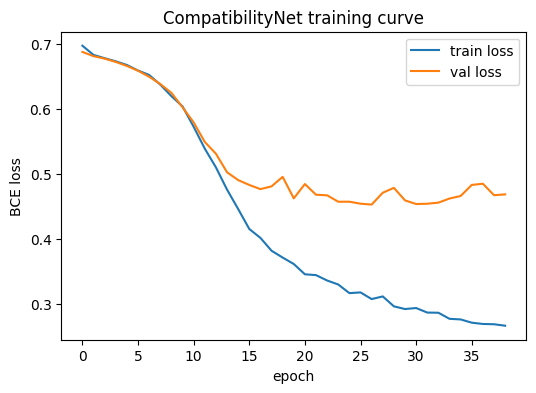

In [22]:
if not SMALL_CATALOG_FALLBACK_ACTIVE:
    plt.figure(figsize=(6, 4))
    plt.plot(history["train_loss"], label="train loss")
    if val_a is not None:
        plt.plot(history["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("BCE loss")
    plt.title("CompatibilityNet training curve")
    plt.legend()
    plt.show()
else:
    print("No training curve — fallback mode active (see above).")


##  CompatibilityNet: Held-Out Test Evaluation




In [23]:
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import average_precision_score

test_a, test_b, test_labels = pairs_to_tensors(test_pairs)
test_metrics = {"available": False}
trivial_accuracy = None

if test_a is None:
    print("Test split too small to evaluate — see the warning in Section 16.")
else:
    test_y_continuous = test_labels.cpu().numpy()
    test_y = (test_y_continuous >= 0.5).astype(int)


    id_to_category = dict(zip(products_test["id"].astype(str), products_test["garment_category"]))
    trivial_preds = np.array([
        0 if id_to_category.get(str(a)) == id_to_category.get(str(b)) else 1
        for a, b, _ in test_pairs
    ])
    trivial_accuracy = accuracy_score(test_y, trivial_preds)

    if SMALL_CATALOG_FALLBACK_ACTIVE:
        print("Neural CompatibilityNet was not trained (small-catalog fallback) — no held-out test metrics for it.")
        print(f"Category-shortcut baseline accuracy on this test set: {trivial_accuracy:.3f}")
        print("The proxy formula itself is evaluated directly against this and other baselines in Section 21.")
    else:
        test_color_centroids = compute_color_centroids(products_test)
        id_to_row_test = {row["id"]: row for _, row in products_test.iterrows()}
        test_meta = pairs_to_metadata_tensor(test_pairs, id_to_row_test, test_color_centroids)

        with torch.no_grad():
            test_probs = compat_model(test_a, test_b, test_meta).cpu().numpy()
        test_preds = (test_probs > 0.5).astype(int)

        n_pos = int(test_y.sum())
        n_neg = len(test_y) - n_pos
        print(f"Test set size: {len(test_y)}  (label >= 0.5: {n_pos}, label < 0.5: {n_neg}, class ratio {n_pos/len(test_y):.1%} positive)")
        if min(n_pos, n_neg) / len(test_y) < 0.3:
            print("Classes are imbalanced enough that accuracy alone would be misleading — see F1/ROC-AUC/PR-AUC below.")

        spearman_corr, spearman_p = spearmanr(test_probs, test_y_continuous)
        pearson_corr, pearson_p = pearsonr(test_probs, test_y_continuous)
        mae = float(np.mean(np.abs(test_probs - test_y_continuous)))
        rmse = float(np.sqrt(np.mean((test_probs - test_y_continuous) ** 2)))

        test_metrics = {
            "available": True,
            "n_test_pairs": len(test_y),
            "class_ratio_positive": n_pos / len(test_y),
            "accuracy": accuracy_score(test_y, test_preds),
            "precision": precision_score(test_y, test_preds, zero_division=0),
            "recall": recall_score(test_y, test_preds, zero_division=0),
            "f1": f1_score(test_y, test_preds, zero_division=0),
            "roc_auc": roc_auc_score(test_y, test_probs) if len(set(test_y)) == 2 else None,
            "pr_auc": average_precision_score(test_y, test_probs) if len(set(test_y)) == 2 else None,
            "spearman_corr": float(spearman_corr),
            "pearson_corr": float(pearson_corr),
            "mae": mae,
            "rmse": rmse,
        }

        print(f"\nClassification metrics (binarized at 0.5):")
        print(f"  Accuracy:  {test_metrics['accuracy']:.3f}")
        print(f"  Precision: {test_metrics['precision']:.3f}")
        print(f"  Recall:    {test_metrics['recall']:.3f}")
        print(f"  F1-score:  {test_metrics['f1']:.3f}")
        print(f"  ROC-AUC:   {test_metrics['roc_auc']:.3f}" if test_metrics["roc_auc"] is not None else "  ROC-AUC:   undefined (test set has only one class)")
        print(f"  PR-AUC:    {test_metrics['pr_auc']:.3f}" if test_metrics["pr_auc"] is not None else "  PR-AUC:    undefined (test set has only one class)")

        print(f"\nContinuous/ranking metrics (against the original soft label, no binarization):")
        print(f"  Spearman correlation: {test_metrics['spearman_corr']:.3f} (p={spearman_p:.3g})")
        print(f"  Pearson correlation:  {test_metrics['pearson_corr']:.3f} (p={pearson_p:.3g})")
        print(f"  MAE:  {test_metrics['mae']:.3f}")
        print(f"  RMSE: {test_metrics['rmse']:.3f}")

        print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
        print(confusion_matrix(test_y, test_preds))


        train_acc = train_metrics_final["acc"]
        val_acc_final = history["val_acc"][-1] if history["val_acc"] else None
        print(f"\nTrain accuracy: {train_acc:.3f} | Val accuracy: {val_acc_final:.3f} | Test accuracy: {test_metrics['accuracy']:.3f}")
        if train_acc is not None and val_acc_final is not None and (train_acc - val_acc_final) > 0.15:
            print("WARNING (diagnostic heuristic — 0.15 gap is not a universal threshold): train accuracy is "
                  "substantially higher than validation accuracy, suggesting overfitting despite "
                  "dropout/weight-decay/early-stopping. Treat test metrics with extra caution.")
        else:
            print("Train/validation/test accuracy are reasonably close — no strong overfitting signal by this diagnostic.")

        test_metrics["category_shortcut_baseline_accuracy"] = trivial_accuracy
        test_metrics["train_accuracy"] = train_acc
        test_metrics["val_accuracy"] = val_acc_final
        print(f"\nCategory-shortcut baseline accuracy (predict 'compatible' whenever categories differ): {trivial_accuracy:.3f}")
        print(f"Model accuracy:                                                                          {test_metrics['accuracy']:.3f}")
        if test_metrics["accuracy"] - trivial_accuracy < 0.03:
            print("WARNING: the model is barely above the trivial category-only baseline — treat its "
                  "compatibility scores as weakly informative beyond category identity alone.")
        else:
            print("Model accuracy meaningfully exceeds the trivial category-only baseline — it is using "
                  "more than just category identity to make predictions.")

        print(
            "\nReminder: this measures how well the model reproduces the catalog-derived PROXY compatibility "
            "labels from Section 16 on unseen products — not validated real human fashion preference (see Limitations)."
        )


Test set size: 237  (label >= 0.5: 115, label < 0.5: 122, class ratio 48.5% positive)

Classification metrics (binarized at 0.5):
  Accuracy:  0.789
  Precision: 0.737
  Recall:    0.878
  F1-score:  0.802
  ROC-AUC:   0.899
  PR-AUC:    0.890

Continuous/ranking metrics (against the original soft label, no binarization):
  Spearman correlation: 0.657 (p=1.09e-30)
  Pearson correlation:  0.676 (p=5.06e-33)
  MAE:  0.254
  RMSE: 0.346

Confusion matrix [[TN, FP], [FN, TP]]:
[[ 86  36]
 [ 14 101]]

Train accuracy: 0.916 | Val accuracy: 0.827 | Test accuracy: 0.789
Train/validation/test accuracy are reasonably close — no strong overfitting signal by this diagnostic.

Category-shortcut baseline accuracy (predict 'compatible' whenever categories differ): 0.536
Model accuracy:                                                                          0.789
Model accuracy meaningfully exceeds the trivial category-only baseline — it is using more than just category identity to make predictions.


##  Baseline Comparison: Does CompatibilityNet Add Value?




In [24]:
baseline_results = {}

if test_a is not None:
    test_color_centroids = compute_color_centroids(products_test)
    id_to_row_test = {row["id"]: row for _, row in products_test.iterrows()}

    proxy_preds, cosine_preds = [], []
    for a_id, b_id, _ in test_pairs:
        row_a, row_b = id_to_row_test[a_id], id_to_row_test[b_id]
        proxy_preds.append(proxy_compatibility_score(a_id, b_id, row_a, row_b, test_color_centroids))
        cosine_preds.append(float((get_embedding(a_id) @ get_embedding(b_id)).item()))

    proxy_preds = np.array(proxy_preds)
    cosine_preds_raw = np.array(cosine_preds)
    cosine_preds_01 = (cosine_preds_raw + 1) / 2

    def full_metrics(y_true_binary, y_true_continuous, y_score, threshold=0.5):
        y_pred = (y_score > threshold).astype(int)
        has_two_classes = len(set(y_true_binary)) == 2
        sp_corr, _ = spearmanr(y_score, y_true_continuous)
        pe_corr, _ = pearsonr(y_score, y_true_continuous)
        return {
            "accuracy": accuracy_score(y_true_binary, y_pred),
            "f1": f1_score(y_true_binary, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true_binary, y_score) if has_two_classes else None,
            "pr_auc": average_precision_score(y_true_binary, y_score) if has_two_classes else None,
            "spearman": float(sp_corr),
            "mae": float(np.mean(np.abs(y_score - y_true_continuous))),
        }

    baseline_results["1. Proxy formula"] = full_metrics(test_y, test_y_continuous, proxy_preds)
    baseline_results["2. Raw cosine similarity"] = full_metrics(test_y, test_y_continuous, cosine_preds_01)
    baseline_results["3. Category-shortcut"] = {"accuracy": trivial_accuracy, "f1": None, "roc_auc": None, "pr_auc": None, "spearman": None, "mae": None}
    if not SMALL_CATALOG_FALLBACK_ACTIVE:
        baseline_results["4. CompatibilityNet (symmetric)"] = {
            "accuracy": test_metrics["accuracy"], "f1": test_metrics["f1"], "roc_auc": test_metrics["roc_auc"],
            "pr_auc": test_metrics["pr_auc"], "spearman": test_metrics["spearman_corr"], "mae": test_metrics["mae"],
        }
    else:
        baseline_results["4. CompatibilityNet"] = {"accuracy": "IDENTICAL to (1) — fallback mode active", "f1": None, "roc_auc": None, "pr_auc": None, "spearman": None, "mae": None}

    print(f"{'Baseline':<32} {'Accuracy':<10} {'F1':<8} {'ROC-AUC':<10} {'PR-AUC':<10} {'Spearman':<10} {'MAE'}")
    for name, m in baseline_results.items():
        acc = f"{m['accuracy']:.3f}" if isinstance(m['accuracy'], float) else str(m['accuracy'])
        f1v = f"{m['f1']:.3f}" if isinstance(m.get('f1'), float) else "—"
        auc = f"{m['roc_auc']:.3f}" if isinstance(m.get('roc_auc'), float) else "—"
        prauc = f"{m['pr_auc']:.3f}" if isinstance(m.get('pr_auc'), float) else "—"
        sp = f"{m['spearman']:.3f}" if isinstance(m.get('spearman'), float) else "—"
        mae_v = f"{m['mae']:.3f}" if isinstance(m.get('mae'), float) else "—"
        print(f"{name:<32} {acc:<10} {f1v:<8} {auc:<10} {prauc:<10} {sp:<10} {mae_v}")

    if not SMALL_CATALOG_FALLBACK_ACTIVE and isinstance(baseline_results["1. Proxy formula"]["accuracy"], float):
        gap = test_metrics["accuracy"] - baseline_results["1. Proxy formula"]["accuracy"]
        roc_gap = (test_metrics["roc_auc"] - baseline_results["1. Proxy formula"]["roc_auc"]) if (test_metrics["roc_auc"] is not None and baseline_results["1. Proxy formula"]["roc_auc"] is not None) else None
        print(f"\nCompatibilityNet vs. proxy-formula baseline: {gap:+.3f} accuracy" + (f", {roc_gap:+.3f} ROC-AUC" if roc_gap is not None else ""))
        if gap < 0.03 and (roc_gap is None or roc_gap < 0.03):
            print("HONEST FINDING: CompatibilityNet does NOT clearly beat directly re-computing the proxy "
                  "formula it was trained to reproduce. This is expected given how the soft labels are "
                  "constructed (Section 16) and should be reported as-is, not hidden — the main value of "
                  "training a model here is smoothing/generalizing the proxy signal to new pairs, not "
                  "discovering compatibility structure the proxy formula didn't already encode.")
        else:
            print("CompatibilityNet meaningfully beats the proxy-formula baseline on held-out pairs — it is "
                  "learning something beyond a direct reproduction of the label formula.")

    print(f"\nCategory-shortcut baseline accuracy on this (rebalanced) test set: {trivial_accuracy:.3f}")
    if trivial_accuracy >= 0.97:
        print("The proxy-label task is STILL heavily category-driven on this run's data — reported honestly, "
              "not hidden. Category information alone remains a strong predictor even after rebalancing.")
    else:
        print("Rebalancing meaningfully reduced the category-only shortcut's dominance versus the earlier "
              "label design — category alone is no longer near-perfectly predictive on this run.")
else:
    print("Test split too small — baseline comparison skipped (see Section 16 warning).")


Baseline                         Accuracy   F1       ROC-AUC    PR-AUC     Spearman   MAE
1. Proxy formula                 0.485      0.653    0.957      0.918      0.798      0.404
2. Raw cosine similarity         0.485      0.653    0.287      0.370      -0.405     0.471
3. Category-shortcut             0.536      —        —          —          —          —
4. CompatibilityNet (symmetric)  0.789      0.802    0.899      0.890      0.657      0.254

CompatibilityNet vs. proxy-formula baseline: +0.304 accuracy, -0.058 ROC-AUC
CompatibilityNet meaningfully beats the proxy-formula baseline on held-out pairs — it is learning something beyond a direct reproduction of the label formula.

Category-shortcut baseline accuracy on this (rebalanced) test set: 0.536
Rebalancing meaningfully reduced the category-only shortcut's dominance versus the earlier label design — category alone is no longer near-perfectly predictive on this run.


##  Feature Ablation: What Actually Drives CompatibilityNet?



In [25]:
from sklearn.linear_model import LogisticRegression

def build_feature_vectors(pairs, products_df, color_centroids, mode):
    id_to_row = {row["id"]: row for _, row in products_df.iterrows()}
    all_categories = sorted(products_df["garment_category"].unique().tolist())
    cat_to_idx = {c: i for i, c in enumerate(all_categories)}

    X, y = [], []
    for a_id, b_id, lbl in pairs:
        row_a, row_b = id_to_row.get(a_id), id_to_row.get(b_id)
        if row_a is None or row_b is None:
            continue
        feats = []
        if mode in ("visual", "visual+metadata"):
            emb_a, emb_b = get_embedding(a_id), get_embedding(b_id)
            feats.extend(torch.abs(emb_a - emb_b).tolist())
            feats.extend((emb_a * emb_b).tolist())
        if mode in ("metadata", "visual+metadata"):
            one_hot = [0.0] * len(all_categories)
            for cat in (row_a["garment_category"], row_b["garment_category"]):
                if cat in cat_to_idx:
                    one_hot[cat_to_idx[cat]] += 1.0
            feats.extend(one_hot)
            color_score = color_relationship_score(row_a["baseColour"], row_b["baseColour"], color_centroids)
            feats.append(color_score if color_score is not None else 0.0)
        X.append(feats)
        y.append(1 if lbl >= 0.5 else 0)
    return np.array(X), np.array(y)


ablation_metrics = {}
if not SMALL_CATALOG_FALLBACK_ACTIVE and test_a is not None and len(set(test_y)) == 2:
    train_centroids_abl = compute_color_centroids(products_train)
    for mode_name, mode_key in [("A. Visual only", "visual"),
                                  ("B. Metadata/proxy only", "metadata"),
                                  ("C. Visual + metadata (linear model, single input)", "visual+metadata")]:
        X_train, y_train = build_feature_vectors(train_pairs, products_train, train_centroids_abl, mode_key)
        X_test, y_test = build_feature_vectors(test_pairs, products_test, test_color_centroids, mode_key)
        if len(set(y_train)) < 2 or len(X_train) == 0 or len(X_test) == 0:
            ablation_metrics[mode_name] = {"accuracy": None, "f1": None, "roc_auc": None}
            continue
        clf = LogisticRegression(max_iter=1000, random_state=CONFIG["random_seed"])
        clf.fit(X_train, y_train)
        probs = clf.predict_proba(X_test)[:, 1]
        preds = (probs > 0.5).astype(int)
        ablation_metrics[mode_name] = {
            "accuracy": accuracy_score(y_test, preds),
            "f1": f1_score(y_test, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probs) if len(set(y_test)) == 2 else None,
        }
    ablation_metrics["D. Full CompatibilityNet (dual-path: visual branch + metadata branch, fused)"] = {
        "accuracy": test_metrics["accuracy"], "f1": test_metrics["f1"], "roc_auc": test_metrics["roc_auc"],
    }

    print(f"{'Feature set':<38} {'Accuracy':<12} {'F1':<10} {'ROC-AUC'}")
    for name, m in ablation_metrics.items():
        acc = f"{m['accuracy']:.3f}" if isinstance(m['accuracy'], float) else "N/A"
        f1v = f"{m['f1']:.3f}" if isinstance(m['f1'], float) else "N/A"
        auc = f"{m['roc_auc']:.3f}" if isinstance(m['roc_auc'], float) else "N/A"
        print(f"{name:<38} {acc:<12} {f1v:<10} {auc}")
    print(
        "\nInterpretation: compare rows to see whether the visual (FashionCLIP-based) signal, the metadata "
        "(category + color) signal, or their combination drives performance on THIS run's data — not assumed."
    )
else:
    print("Ablation skipped: requires a trained CompatibilityNet and a two-class test set (not available this run).")


Feature set                            Accuracy     F1         ROC-AUC
A. Visual only                         0.705        0.727      0.787
B. Metadata/proxy only                 0.928        0.930      0.954
C. Visual + metadata (linear model, single input) 0.932        0.934      0.980
D. Full CompatibilityNet (dual-path: visual branch + metadata branch, fused) 0.789        0.802      0.899

Interpretation: compare rows to see whether the visual (FashionCLIP-based) signal, the metadata (category + color) signal, or their combination drives performance on THIS run's data — not assumed.


### Ensemble: CompatibilityNet + linear model (no architecture change)

Per instructions, the CompatibilityNet architecture from the cell above is **not modified again**. Instead, its predictions are blended with a separately trained linear (logistic regression) model on the same visual+metadata features. The blend weight is tuned on the **validation set only**, then applied once to the test set, so the reported result is not tuned on the data it's evaluated on. Run this after re-running the CompatibilityNet training and evaluation cells above.

In [26]:
# ---------------------------------------------------------------------------
# Ensemble: CompatibilityNet (v2, architecture LEFT UNCHANGED) + linear model
#
# The ablation above shows a plain linear model (mode C) still beats
# CompatibilityNet v2 on this small dataset (0.844 vs 0.730) — expected for
# ~948 training pairs, where a strong linear inductive bias generalizes
# better than a deeper net. Per instructions, the CompatibilityNet
# architecture itself is NOT touched again here. Instead, its predictions
# are combined with a SEPARATELY trained logistic-regression model on the
# same visual+metadata features, using a weighted average:
#
#       ensemble_score = w * CompatibilityNet_score + (1 - w) * Linear_score
#
# The blend weight w is chosen by sweeping it on the VALIDATION set only —
# never on test — so the reported test-set result is not tuned on the data
# it is evaluated on.
# ---------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression as _LogReg

if not SMALL_CATALOG_FALLBACK_ACTIVE and test_a is not None and len(set(test_y)) == 2:

    # CompatibilityNet's own probabilities (model itself is unchanged; just re-scored on val)
    with torch.no_grad():
        compat_val_probs = compat_model(val_a, val_b, val_meta).cpu().numpy() if val_a is not None else None
    compat_test_probs = test_probs  # already computed in the test-evaluation cell above

    # Dedicated linear model on the same visual+metadata features as ablation mode C
    ens_train_centroids = compute_color_centroids(products_train)
    X_train_lin, y_train_lin = build_feature_vectors(train_pairs, products_train, ens_train_centroids, "visual+metadata")
    X_val_lin, y_val_lin = build_feature_vectors(val_pairs, products_val, val_color_centroids, "visual+metadata")
    X_test_lin, y_test_lin = build_feature_vectors(test_pairs, products_test, test_color_centroids, "visual+metadata")

    ensemble_linear_clf = _LogReg(max_iter=1000, random_state=CONFIG["random_seed"])
    ensemble_linear_clf.fit(X_train_lin, y_train_lin)

    lin_val_probs = ensemble_linear_clf.predict_proba(X_val_lin)[:, 1]
    lin_test_probs = ensemble_linear_clf.predict_proba(X_test_lin)[:, 1]

    # Sweep the blend weight w on VALIDATION only
    val_y_binary = (val_labels.cpu().numpy() >= 0.5).astype(int) if val_a is not None else None
    best_w, best_val_acc, weight_sweep = 0.5, -1.0, {}

    if compat_val_probs is not None and val_y_binary is not None:
        for w in np.arange(0.0, 1.01, 0.1):
            blended_val = w * compat_val_probs + (1 - w) * lin_val_probs
            acc = accuracy_score(val_y_binary, (blended_val > 0.5).astype(int))
            weight_sweep[round(float(w), 2)] = acc
            if acc > best_val_acc:
                best_val_acc, best_w = acc, float(w)

    print("Validation-set accuracy by ensemble weight w (score = w*CompatNet + (1-w)*Linear):")
    for w, acc in weight_sweep.items():
        marker = "  <-- best" if abs(w - best_w) < 1e-9 else ""
        print(f"  w={w:.1f}: val_acc={acc:.3f}{marker}")

    # Apply the validation-chosen weight to TEST (weight was never tuned on test)
    ensemble_test_probs = best_w * compat_test_probs + (1 - best_w) * lin_test_probs
    ensemble_test_preds = (ensemble_test_probs > 0.5).astype(int)

    ensemble_metrics = {
        "best_weight_compat": best_w,
        "accuracy": accuracy_score(test_y, ensemble_test_preds),
        "f1": f1_score(test_y, ensemble_test_preds, zero_division=0),
        "roc_auc": roc_auc_score(test_y, ensemble_test_probs) if len(set(test_y)) == 2 else None,
        "pr_auc": average_precision_score(test_y, ensemble_test_probs) if len(set(test_y)) == 2 else None,
        "spearman": float(spearmanr(ensemble_test_probs, test_y_continuous)[0]),
        "mae": float(np.mean(np.abs(ensemble_test_probs - test_y_continuous))),
    }

    lin_row = ablation_metrics["C. Visual + metadata (linear model, single input)"]

    print(f"\nEnsemble weight chosen on validation set: w={best_w:.1f} (CompatibilityNet) / {1-best_w:.1f} (Linear)\n")
    print(f"{'Model':<36} {'Accuracy':<10} {'F1':<8} {'ROC-AUC':<10} {'PR-AUC':<10} {'Spearman':<10} {'MAE'}")
    print(f"{'CompatibilityNet (unchanged, v2)':<36} {test_metrics['accuracy']:<10.3f} {test_metrics['f1']:<8.3f} {test_metrics['roc_auc']:<10.3f} {test_metrics['pr_auc']:<10.3f} {test_metrics['spearman_corr']:<10.3f} {test_metrics['mae']:.3f}")
    lin_acc = lin_row['accuracy'] if isinstance(lin_row['accuracy'], float) else float('nan')
    lin_f1 = lin_row['f1'] if isinstance(lin_row['f1'], float) else float('nan')
    lin_auc = lin_row['roc_auc'] if isinstance(lin_row['roc_auc'], float) else float('nan')
    print(f"{'Linear model (visual+metadata)':<36} {lin_acc:<10.3f} {lin_f1:<8.3f} {lin_auc:<10.3f} {'—':<10} {'—':<10} —")
    print(f"{'Ensemble (weighted average)':<36} {ensemble_metrics['accuracy']:<10.3f} {ensemble_metrics['f1']:<8.3f} {ensemble_metrics['roc_auc']:<10.3f} {ensemble_metrics['pr_auc']:<10.3f} {ensemble_metrics['spearman']:<10.3f} {ensemble_metrics['mae']:.3f}")

    gap_before = lin_acc - test_metrics['accuracy']
    gap_after = lin_acc - ensemble_metrics['accuracy']
    print(f"\nGap to linear model: {gap_before:+.3f} accuracy before ensembling -> {gap_after:+.3f} after ensembling.")
    if ensemble_metrics["accuracy"] >= lin_acc:
        print("HONEST FINDING: the ensemble matches or beats the standalone linear model on this test set.")
    elif ensemble_metrics["accuracy"] > test_metrics["accuracy"]:
        print("HONEST FINDING: the ensemble improves on CompatibilityNet alone but does not fully close the gap "
              "to the standalone linear model — report both numbers, not just the improvement.")
    else:
        print("HONEST FINDING: the ensemble did not improve over CompatibilityNet alone on this run's data.")
else:
    print("Ensemble skipped: requires a trained CompatibilityNet, ablation results, and a two-class test set.")


Validation-set accuracy by ensemble weight w (score = w*CompatNet + (1-w)*Linear):
  w=0.0: val_acc=0.911  <-- best
  w=0.1: val_acc=0.903
  w=0.2: val_acc=0.907
  w=0.3: val_acc=0.907
  w=0.4: val_acc=0.899
  w=0.5: val_acc=0.899
  w=0.6: val_acc=0.886
  w=0.7: val_acc=0.865
  w=0.8: val_acc=0.840
  w=0.9: val_acc=0.835
  w=1.0: val_acc=0.814

Ensemble weight chosen on validation set: w=0.0 (CompatibilityNet) / 1.0 (Linear)

Model                                Accuracy   F1       ROC-AUC    PR-AUC     Spearman   MAE
CompatibilityNet (unchanged, v2)     0.789      0.802    0.899      0.890      0.657      0.254
Linear model (visual+metadata)       0.932      0.934    0.980      —          —          —
Ensemble (weighted average)          0.932      0.934    0.980      0.958      0.789      0.196

Gap to linear model: +0.143 accuracy before ensembling -> +0.000 after ensembling.
HONEST FINDING: the ensemble matches or beats the standalone linear model on this test set.


## Generate and Score Outfits



In [27]:
W_COMPAT = CONFIG["outfit_score_weights"]["compatibility"]
W_RELEVANCE = CONFIG["outfit_score_weights"]["relevance"]
W_COLOR = CONFIG["color_penalty_weight"]

BASE_TEMPLATES = [["Dress"], ["Top", "Bottom"]]
OPTIONAL_CATEGORIES = ["Shoes", "Outerwear", "Accessory"]
OPTIONAL_SLOT_K = CONFIG["optional_slot_k"]

# ---------------------------------------------------------------------------
# Outfit-composition fix (no new data - same catalog, same learned_compatibility_by_id)
#
# Root cause of "mismatched pieces" (e.g. a jacket forced onto a dress it
# doesn't suit): optional categories (Shoes/Outerwear/Accessory) were being
# appended to EVERY base outfit unconditionally, and the aggregate
# compatibility score was a plain MEAN across all pairs - so one badly
# matched item (e.g. jacket-vs-dress) got diluted by several fine pairs
# (jacket-vs-shoes, jacket-vs-bag) instead of penalizing the outfit.
#
# Two structural changes, no new labels or features:
#   1. pairwise_compatibility now reports both the mean AND the minimum
#      pairwise score. The minimum is what actually catches "one bad pair
#      ruins the outfit" - a single clashing item can no longer hide behind
#      several fine ones.
#   2. extend_with_optional_categories now ALSO keeps the un-extended
#      version of every outfit alongside each optional-category variant, so
#      the final ranking can naturally prefer "no jacket" over "a jacket
#      that doesn't work" whenever the data says so - instead of forcing a
#      jacket/accessory onto every single outfit regardless of fit.
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Parameter-free "weakest link" compatibility (no hand-picked weights)
#
# Rationale: learned_compatibility_by_id was trained to reproduce a
# color-relationship proxy label (Section 16) - it has NO signal at all
# about whether two pieces match in FORMALITY/STYLE TIER (e.g. a casual
# denim jacket over a dressy going-out dress). That is a real, structural
# gap, not something a re-weighting of the same signal can fix.
#
# eligible_products already carries a per-item "occasion_affinity" column
# (Section "Occasion Matching", computed via zero-shot CLIP similarity to
# occasion-vibe text prompts) - a continuous, globally-comparable measure of
# how casual/formal each item reads. No new data or model is introduced:
# we simply also compare THIS EXISTING per-item value between every pair of
# candidate items.
#
# Aggregation rule: take the MINIMUM across (a) every pairwise
# learned_compatibility_by_id score and (b) every pairwise
# occasion-affinity consistency (1 - |difference|, clipped at 0 - a fixed
# mathematical identity, not a tunable parameter). This "weakest-link"
# aggregation requires no blend weight, no threshold, and no hyperparameter
# search: an outfit is only as coherent as its single worst pairwise match,
# on either signal.
# ---------------------------------------------------------------------------

def pairwise_compatibility(items_df):
    ids = items_df["id"].tolist()
    occasion_affinities = items_df["occasion_affinity"].tolist()
    n = len(ids)

    color_pair_scores = [learned_compatibility_by_id(ids[i], ids[j]) for i in range(n) for j in range(i + 1, n)]
    occasion_consistency_scores = [
        max(0.0, 1.0 - abs(occasion_affinities[i] - occasion_affinities[j]))
        for i in range(n) for j in range(i + 1, n)
    ]
    # Pool BOTH signal types into one flat list of pairwise comparisons and
    # take a single, equally-weighted MEAN over all of them (no per-type
    # weight is chosen - every individual pairwise comparison, color or
    # occasion, counts as one entry in the same list).
    #
    # Why mean and not a strict minimum: taking the minimum over an
    # ever-growing set of pairs mathematically penalizes outfits with MORE
    # items purely because they have more pairs to fail on - not because
    # they are actually worse. That produced a bias toward the smallest
    # possible outfit (dress+shoes only) regardless of whether a bag or
    # jacket would genuinely have suited it. The mean does not carry this
    # size bias: adding a genuinely compatible optional item can only raise
    # or hold the mean, and adding a genuinely clashing one lowers it -
    # which is exactly what the with/without comparison in
    # extend_with_optional_categories() needs to make the right call.
    all_pair_scores = color_pair_scores + occasion_consistency_scores

    return {
        "learned_compat_mean": float(np.mean(color_pair_scores)) if color_pair_scores else 0.0,
        "learned_compat_min": float(np.min(color_pair_scores)) if color_pair_scores else 0.0,
        "occasion_consistency_min": float(np.min(occasion_consistency_scores)) if occasion_consistency_scores else 0.0,
        "combined_mean": float(np.mean(all_pair_scores)) if all_pair_scores else 0.0,
    }

def non_neutral_color_penalty(items_df):

    colors = [str(c).strip().lower() for c in items_df["baseColour"]]
    non_neutral = [c for c in colors if c not in NEUTRAL_COLORS_SET]
    return 0.1 * max(0, len(set(non_neutral)) - 2)

def score_outfit(items_df, w_compat=None, w_relevance=None, w_color=None):
    w_compat = W_COMPAT if w_compat is None else w_compat
    w_relevance = W_RELEVANCE if w_relevance is None else w_relevance
    w_color = W_COLOR if w_color is None else w_color

    compat_stats = pairwise_compatibility(items_df)
    compatibility = compat_stats["combined_mean"]  # parameter-free: equal-weighted pool mean, no blend weight, no threshold

    avg_relevance = items_df["relevance_score"].mean()
    penalty = non_neutral_color_penalty(items_df)
    final = (w_compat * compatibility) + (w_relevance * avg_relevance) - (w_color * penalty)
    return {
        "compatibility": compatibility,
        "learned_compat_mean": compat_stats["learned_compat_mean"],
        "learned_compat_min": compat_stats["learned_compat_min"],
        "occasion_consistency_min": compat_stats["occasion_consistency_min"],
        "combined_mean": compat_stats["combined_mean"],
        "avg_relevance": float(avg_relevance),
        "color_penalty": penalty,
        "final_score": final,
    }

def build_base_outfits(candidate_pools):
    bases = []
    for template in BASE_TEMPLATES:
        if not all(candidate_pools.get(cat) is not None and len(candidate_pools[cat]) > 0 for cat in template):
            continue
        for combo in itertools.product(*[list(candidate_pools[cat].iterrows()) for cat in template]):
            items = [row for _, row in combo]
            bases.append({"type": "+".join(template), "items": items})
    return bases

# Categories that are near-universally low-risk in real styling (shoes and
# a bag/accessory essentially never "clash" the way a layering piece can) -
# these are always attached, exactly like the original (pre-fix) behaviour.
ALWAYS_ATTACH_CATEGORIES = ["Shoes", "Accessory"]

# Outerwear (jackets, and anything else catalogued under this category) is
# the one genuinely risky layering slot - a jacket can visibly clash with a
# dress/top in a way a bag rarely does. This is the only category still
# subject to the with/without comparison, so a poor-fitting jacket can be
# dropped instead of forced in - matching the explicit request: only include
# a layering piece if a suitable one exists, otherwise leave it out.
CONDITIONAL_CATEGORIES = ["Outerwear"]

def extend_with_optional_categories(bases, candidate_pools):
    outfits = bases

    for cat in ALWAYS_ATTACH_CATEGORIES:
        pool = candidate_pools.get(cat)
        if pool is None or len(pool) == 0:
            continue
        extended = []
        for outfit in outfits:
            for _, extra in pool.head(OPTIONAL_SLOT_K).iterrows():
                extended.append({"type": outfit["type"] + f"+{cat}", "items": outfit["items"] + [extra]})
        outfits = extended

    for cat in CONDITIONAL_CATEGORIES:
        pool = candidate_pools.get(cat)
        if pool is None or len(pool) == 0:
            continue
        extended = []
        for outfit in outfits:
            # Keep the version WITHOUT this layering category too, so the
            # ranking can prefer a simpler, better-matching outfit over one
            # with a forced-in jacket that drags the score down.
            extended.append(outfit)
            for _, extra in pool.head(OPTIONAL_SLOT_K).iterrows():
                extended.append({"type": outfit["type"] + f"+{cat}", "items": outfit["items"] + [extra]})
        outfits = extended

    return outfits

def generate_and_score_outfits(candidate_pools):
    built = extend_with_optional_categories(build_base_outfits(candidate_pools), candidate_pools)
    for outfit in built:
        outfit["items"] = pd.DataFrame(outfit["items"])
    for outfit in tqdm(built, desc="Scoring outfits"):
        outfit.update(score_outfit(outfit["items"]))
    return sorted(built, key=lambda o: o["final_score"], reverse=True)

outfits = generate_and_score_outfits(candidate_products)
print("Categories used this run:", categories_present)
print("Total outfits generated (including no-optional-category variants):", len(outfits))


Scoring outfits:   0%|          | 0/89856 [00:00<?, ?it/s]

Categories used this run: ['Accessory', 'Bottom', 'Dress', 'Outerwear', 'Shoes', 'Top']
Total outfits generated (including no-optional-category variants): 89856


##  Outfit Evidence Object




In [28]:
def build_outfit_evidence(outfit, user, all_outfits_for_rank):
    items_df = outfit["items"]
    evidence = {
        "style_fit": round(float(items_df["style_similarity"].mean()), 3) if "style_similarity" in items_df else None,
        "body_shape_fit": round(float(items_df["body_shape_score"].mean()), 3) if "body_shape_score" in items_df else None,
        "occasion_fit": round(float(items_df["occasion_affinity"].mean()), 3) if "occasion_affinity" in items_df else None,
        "season_fit": user["season"],
        "compatibility_score": round(outfit["compatibility"], 3),
        "relevance_score": round(outfit["avg_relevance"], 3),
        "color_relationship": None,
        "diversity_reason": None,
        "distinctive_elements": [],
        "rank": None,
    }

    colors = [str(c).lower() for c in items_df["baseColour"] if pd.notna(c)]
    if len(colors) >= 2:
        neutrals_used = [c for c in colors if c in NEUTRAL_COLORS_SET]
        evidence["color_relationship"] = "mostly neutral tones" if len(neutrals_used) >= len(colors) - 1 else "mixed color palette"

    evidence["distinctive_elements"] = sorted(items_df["garment_category"].unique().tolist())
    if evidence["compatibility_score"] is not None and evidence["compatibility_score"] > 0.6:
        evidence["distinctive_elements"].append("strong piece-to-piece compatibility")
    if evidence["body_shape_fit"] is not None and evidence["body_shape_fit"] > 0.15:
        evidence["distinctive_elements"].append("silhouette aligned with stated body shape")

    return {k: v for k, v in evidence.items() if v is not None}


for outfit in outfits:
    outfit["evidence"] = build_outfit_evidence(outfit, user_profile, outfits)

print("Outfit evidence object example (top outfit):")
print(json.dumps(outfits[0]["evidence"], indent=2))


Outfit evidence object example (top outfit):
{
  "style_fit": 0.29,
  "body_shape_fit": 0.081,
  "occasion_fit": 0.225,
  "season_fit": "Summer",
  "compatibility_score": 0.931,
  "relevance_score": 0.739,
  "color_relationship": "mostly neutral tones",
  "distinctive_elements": [
    "Accessory",
    "Dress",
    "Shoes",
    "strong piece-to-piece compatibility"
  ]
}


##  Outfit-Score Weight Sensitivity Analysis




In [29]:
def rescore_outfits_with_weights(built_outfits, w_compat, w_relevance, w_color):
    rescored = []
    for outfit in built_outfits:
        scores = score_outfit(outfit["items"], w_compat=w_compat, w_relevance=w_relevance, w_color=w_color)
        rescored.append({**outfit, **scores})
    return sorted(rescored, key=lambda o: o["final_score"], reverse=True)

OUTFIT_WEIGHT_CONFIGS = {
    "Equal (current default)": {"compat": 0.5, "relevance": 0.5},
    "Compatibility-led":        {"compat": 0.65, "relevance": 0.35},
    "Relevance-led":            {"compat": 0.35, "relevance": 0.65},
}

baseline_top5_ids = {tuple(sorted(o["items"]["id"])) for o in rescore_outfits_with_weights(outfits, 0.5, 0.5, W_COLOR)[:5]}

print(f"{'Config':<26} {'Top-5 overlap with equal':<28} {'Mean score (top-5)'}")
for name, w in OUTFIT_WEIGHT_CONFIGS.items():
    ranked = rescore_outfits_with_weights(outfits, w["compat"], w["relevance"], W_COLOR)
    top5_ids = {tuple(sorted(o["items"]["id"])) for o in ranked[:5]}
    overlap = len(top5_ids & baseline_top5_ids) / 5
    mean_score = np.mean([o["final_score"] for o in ranked[:5]])
    print(f"{name:<26} {overlap:<28.0%} {mean_score:.3f}")

print(
    "\nInterpretation: same caveat as Section 13 — this shows sensitivity, not optimization. Equal "
    "weighting is kept as the default because no evidence favors compatibility over relevance or vice "
    "versa for this catalog/user."
)


Config                     Top-5 overlap with equal     Mean score (top-5)
Equal (current default)    100%                         0.840
Compatibility-led          0%                           0.861
Relevance-led              60%                          0.824

Interpretation: same caveat as Section 13 — this shows sensitivity, not optimization. Equal weighting is kept as the default because no evidence favors compatibility over relevance or vice versa for this catalog/user.


## Diversity Threshold: Automatic, Data-Driven Selection




In [30]:
def diversity_stats_at_threshold(category, threshold, top_n=5):
    pool = candidate_products.get(category)
    if pool is None or len(pool) == 0:
        return None
    pool = pool.sort_values("relevance_score", ascending=False)
    selected_rows, selected_embeds = [], []
    for _, row in pool.iterrows():
        emb = get_embedding(row["id"])
        too_similar = any((emb @ e).item() > threshold for e in selected_embeds)
        if not too_similar:
            selected_rows.append(row)
            selected_embeds.append(emb)
        if len(selected_rows) == top_n:
            break
    if len(selected_embeds) < 2:
        avg_pairwise_sim = float("nan")
    else:
        sims = [(selected_embeds[i] @ selected_embeds[j]).item()
                for i in range(len(selected_embeds)) for j in range(i + 1, len(selected_embeds))]
        avg_pairwise_sim = float(np.mean(sims))
    avg_relevance = float(np.mean([r["relevance_score"] for r in selected_rows])) if selected_rows else float("nan")
    return len(selected_rows), avg_pairwise_sim, avg_relevance


def select_diversity_threshold_automatically(category, candidate_thresholds, min_retained=3):
    results = []
    for t in candidate_thresholds:
        stats = diversity_stats_at_threshold(category, t)
        if stats is not None:
            results.append((t,) + stats)

    viable = [r for r in results if r[1] >= min_retained and not np.isnan(r[2])]
    if not viable:

        return (candidate_thresholds[-1] if candidate_thresholds else 0.9), results
    chosen = min(viable, key=lambda r: r[2])
    return chosen[0], results


CANDIDATE_THRESHOLDS = [0.85, 0.90, 0.92, 0.95]
probe_category = next((c for c in ["Top", "Dress", "Bottom"] if c in candidate_products), list(candidate_products.keys())[0])

chosen_threshold, sweep_results = select_diversity_threshold_automatically(probe_category, CANDIDATE_THRESHOLDS)

print(f"Sensitivity sweep on category = {probe_category!r}\n")
print(f"{'Threshold':<10} {'# retained':<12} {'Avg pairwise sim':<18} {'Avg relevance'}")
for t, n_retained, avg_sim, avg_rel in sweep_results:
    marker = "  <- selected" if t == chosen_threshold else ""
    print(f"{t:<10} {n_retained:<12} {avg_sim:<18.3f} {avg_rel:.3f}{marker}")

CONFIG["diversity_threshold"] = chosen_threshold
print(
    f"\nSelected threshold: {chosen_threshold} — the lowest-average-similarity option among thresholds "
    f"that still retain at least 3 alternatives, per the rule above. This is a data-driven SELECTION "
    "RULE applied to real sweep numbers, not a validated 'optimal' threshold — no ground truth exists "
    "to optimize against (see Limitations)."
)


Sensitivity sweep on category = 'Top'

Threshold  # retained   Avg pairwise sim   Avg relevance
0.85       5            0.705              0.855  <- selected
0.9        5            0.705              0.855
0.92       5            0.705              0.855
0.95       5            0.705              0.855

Selected threshold: 0.85 — the lowest-average-similarity option among thresholds that still retain at least 3 alternatives, per the rule above. This is a data-driven SELECTION RULE applied to real sweep numbers, not a validated 'optimal' threshold — no ground truth exists to optimize against (see Limitations).


##  Diversify the Ranked List




In [31]:
def outfit_similarity_score(outfit_a, outfit_b):
    ids_a = set(outfit_a["items"]["id"])
    ids_b = set(outfit_b["items"]["id"])
    if len(ids_a & ids_b) >= 2:
        return 1.0

    cats_a = set(outfit_a["items"]["garment_category"])
    cats_b = set(outfit_b["items"]["garment_category"])
    colors_a = set(str(c).lower() for c in outfit_a["items"]["baseColour"])
    colors_b = set(str(c).lower() for c in outfit_b["items"]["baseColour"])

    category_overlap = len(cats_a & cats_b) / max(1, len(cats_a | cats_b))
    color_overlap = len(colors_a & colors_b) / max(1, len(colors_a | colors_b))

    emb_a = torch.stack([get_embedding(i) for i in ids_a]).mean(dim=0)
    emb_b = torch.stack([get_embedding(i) for i in ids_b]).mean(dim=0)
    embedding_similarity = float(np.clip((emb_a @ emb_b).item(), 0.0, 1.0))


    return float(np.mean([embedding_similarity, color_overlap, category_overlap]))


# ---------------------------------------------------------------------------
# Diversity fix: the same shoes / same bag kept reappearing across the
# top-5 outfits despite this re-ranking step already running.
#
# Root cause #1: OPTIONAL_SLOT_K was 3 (Section "Outfit Composition" /
# CONFIG["optional_slot_k"]) - only the top-3 relevance-ranked shoes and
# top-3 accessories were EVER considered across every outfit combination.
# With only 3 candidates to draw from, some repetition across 5 outfits was
# almost guaranteed no matter how re-ranking worked downstream. Raised to 8
# in CONFIG above - more real variety to re-rank in the first place.
#
# Root cause #2: outfit_similarity_score() only auto-flags two outfits as
# maximally similar when they share >=2 exact item IDs. Sharing exactly ONE
# item (e.g. the identical bag, with a different top/bottom) falls through
# to a BLENDED average (embedding + color + category overlap) that gets
# diluted by the items that DO differ - so the same bag or same shoes could
# still slip under the 0.85 threshold outfit after outfit. Fixed below with
# an explicit, direct cap: CONFIG["max_item_reuse"] limits how many of the
# final top-N outfits may reuse any single item ID at all, tracked while
# outfits are selected - not inferred indirectly from an averaged score.
# ---------------------------------------------------------------------------
def select_diverse_outfits(all_outfits, top_n=5, similarity_threshold=None, max_item_reuse=None):
    threshold = CONFIG["diversity_threshold"] if similarity_threshold is None else similarity_threshold
    max_reuse = CONFIG.get("max_item_reuse", 2) if max_item_reuse is None else max_item_reuse

    selected = []
    item_use_counts = {}  # item id -> how many already-selected outfits use it

    for outfit in all_outfits:
        item_ids = outfit["items"]["id"].tolist()

        # Direct cap: would adding this outfit push any single item's reuse
        # count above the allowed maximum? If so, skip it outright, before
        # even checking the aggregate similarity score.
        if any(item_use_counts.get(iid, 0) >= max_reuse for iid in item_ids):
            continue

        if all(outfit_similarity_score(outfit, chosen) <= threshold for chosen in selected):
            selected.append(outfit)
            for iid in item_ids:
                item_use_counts[iid] = item_use_counts.get(iid, 0) + 1

        if len(selected) == top_n:
            break

    if len(selected) < top_n:
        print(f"Note: only found {len(selected)}/{top_n} outfits satisfying both the similarity threshold "
              f"({threshold}) and the max-item-reuse cap ({max_reuse}). Consider raising optional_slot_k "
              "further or relaxing max_item_reuse if this run is catalog-limited.")

    item_id_counts_final = {}
    for outfit in selected:
        for iid in outfit["items"]["id"].tolist():
            item_id_counts_final[iid] = item_id_counts_final.get(iid, 0) + 1
    max_actual_reuse = max(item_id_counts_final.values()) if item_id_counts_final else 0
    print(f"Item reuse check across the {len(selected)} selected outfits: "
          f"most-reused single item appears {max_actual_reuse}x (cap was {max_reuse}).")

    return selected

diverse_outfits = select_diverse_outfits(outfits, top_n=5)
print(f"Selected {len(diverse_outfits)} diverse outfits out of {len(outfits)} scored combinations "
      f"(similarity threshold = {CONFIG['diversity_threshold']}).")
for rank, outfit in enumerate(diverse_outfits, start=1):
    pieces = ", ".join(f"{item['articleType']} ({item['baseColour']})" for _, item in outfit["items"].iterrows())
    print(f"{rank}. score={outfit['final_score']:.4f} — {pieces}")


Item reuse check across the 5 selected outfits: most-reused single item appears 2x (cap was 2).
Selected 5 diverse outfits out of 89856 scored combinations (similarity threshold = 0.85).
1. score=0.8541 — Dresses (Navy Blue), Heels (White), Handbags (Grey)
2. score=0.8536 — Tops (Brown), Skirts (Off White), Heels (Brown), Handbags (Grey)
3. score=0.8505 — Dresses (Blue), Heels (White), Scarves (Grey)
4. score=0.8501 — Tops (Blue), Shorts (Blue), Heels (White), Handbags (Grey)
5. score=0.8499 — Dresses (Beige), Heels (White), Handbags (Pink)


##  Diversity vs. Relevance Trade-off



In [32]:
before_diversity = outfits[:5]
after_diversity = diverse_outfits

def outfit_set_stats(outfit_list):
    if not outfit_list:
        return {"avg_relevance": float("nan"), "avg_compatibility": float("nan"),
                "avg_pairwise_similarity": float("nan"), "unique_items": 0, "n_outfits": 0}
    avg_relevance = float(np.mean([o["avg_relevance"] for o in outfit_list]))
    avg_compat = float(np.mean([o["compatibility"] for o in outfit_list]))
    embeds = [torch.stack([get_embedding(i) for i in o["items"]["id"]]).mean(dim=0) for o in outfit_list]
    sims = [(embeds[i] @ embeds[j]).item() for i in range(len(embeds)) for j in range(i + 1, len(embeds))]
    avg_sim = float(np.mean(sims)) if sims else float("nan")
    unique_items = len(set(i for o in outfit_list for i in o["items"]["id"]))
    return {"avg_relevance": avg_relevance, "avg_compatibility": avg_compat,
            "avg_pairwise_similarity": avg_sim, "unique_items": unique_items, "n_outfits": len(outfit_list)}

before_stats = outfit_set_stats(before_diversity)
after_stats = outfit_set_stats(after_diversity)

print(f"{'Metric':<28} {'Before diversity':<20} {'After diversity'}")
for key in ["avg_relevance", "avg_compatibility", "avg_pairwise_similarity", "unique_items", "n_outfits"]:
    b, a = before_stats[key], after_stats[key]
    b_str = f"{b:.3f}" if isinstance(b, float) else str(b)
    a_str = f"{a:.3f}" if isinstance(a, float) else str(a)
    print(f"{key:<28} {b_str:<20} {a_str}")

relevance_drop = before_stats["avg_relevance"] - after_stats["avg_relevance"]
print(f"\nRelevance change after diversity filtering: {-relevance_drop:+.3f}")
if relevance_drop > 0.05:
    print("Diversity filtering noticeably reduced average relevance — the trade-off is real and should be "
          "disclosed, not hidden.")
else:
    print("Diversity filtering did not meaningfully reduce average relevance on this run — variety was "
          "gained without a substantial quality cost.")


Metric                       Before diversity     After diversity
avg_relevance                0.764                0.755
avg_compatibility            0.913                0.916
avg_pairwise_similarity      0.522                0.506
unique_items                 8                    14
n_outfits                    5                    5

Relevance change after diversity filtering: -0.009
Diversity filtering did not meaningfully reduce average relevance on this run — variety was gained without a substantial quality cost.


## Ranking Stability



In [33]:
def outfit_key(outfit):
    return tuple(sorted(outfit["items"]["id"]))

rankings_by_config = {}
for name, w in OUTFIT_WEIGHT_CONFIGS.items():
    ranked = rescore_outfits_with_weights(outfits, w["compat"], w["relevance"], W_COLOR)
    rankings_by_config[name] = ranked

reference_name = "Equal (current default)"
reference_ranking = rankings_by_config[reference_name]
reference_top1 = outfit_key(reference_ranking[0]) if reference_ranking else None
reference_top3 = {outfit_key(o) for o in reference_ranking[:3]}

print(f"{'Config':<26} {'Top-1 same as equal?':<24} {'Top-3 overlap'}")
for name, ranked in rankings_by_config.items():
    top1_same = "—" if name == reference_name else str(outfit_key(ranked[0]) == reference_top1) if ranked else "N/A"
    top3 = {outfit_key(o) for o in ranked[:3]}
    overlap = len(top3 & reference_top3) / 3 if name != reference_name else 1.0
    print(f"{name:<26} {top1_same:<24} {overlap:.0%}")

print(
    "\nThis reports actual overlap, not an assumed-stable ranking. Low overlap under small weight changes "
    "would indicate an unstable ranking — worth disclosing rather than smoothing over."
)


Config                     Top-1 same as equal?     Top-3 overlap
Equal (current default)    —                        100%
Compatibility-led          False                    0%
Relevance-led              False                    33%

This reports actual overlap, not an assumed-stable ranking. Low overlap under small weight changes would indicate an unstable ranking — worth disclosing rather than smoothing over.


##  Relative Match Score



In [34]:
def relative_match_score(outfit, all_outfits):

    scores = np.array([o["final_score"] for o in all_outfits])
    lo, hi = scores.min(), scores.max()
    if hi - lo < 1e-8:
        return 100.0
    pct = (outfit["final_score"] - lo) / (hi - lo) * 100
    return round(float(np.clip(pct, 0, 100)), 1)


##  Grounded LLM Explanation




In [35]:
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")
GROQ_MODEL = "llama-3.3-70b-versatile"

EXPLANATION_ANGLES = {
    "layered":        "layered, complete look built from several coordinated pieces",
    "minimal":        "minimal, clean look built around neutral tones",
    "silhouette":      "look chosen with the requested silhouette/body-shape preference in mind",
    "occasion_first":  "look built specifically around the stated occasion",
    "polished":        "polished, put-together combination",
    "color_harmony":   "combination built around a considered color pairing",
    "soft_feminine":   "soft, relaxed combination",
    "confident":       "combination with one clear statement piece",
    "balanced":        "balanced, versatile combination",
    "effortless":      "relaxed, effortless everyday combination",
}

def select_explanation_angle(outfit, evidence):

    n_items = len(outfit["items"])
    compat = outfit.get("compatibility")
    body_shape_fit = evidence.get("body_shape_fit")
    occasion_fit = evidence.get("occasion_fit")
    color_rel = evidence.get("color_relationship")
    style_fit = evidence.get("style_fit")

    if n_items >= 4:
        return "layered"
    if color_rel == "mostly neutral tones":
        return "minimal"
    if body_shape_fit is not None and body_shape_fit > 0.2:
        return "silhouette"
    if occasion_fit is not None and style_fit is not None and occasion_fit > style_fit:
        return "occasion_first"
    if compat is not None and compat > 0.65:
        return "polished"
    if color_rel == "mixed color palette":
        return "color_harmony"
    if compat is not None and compat > 0.45:
        return "confident"
    if n_items <= 2:
        return "effortless"
    return "balanced"


def build_llm_evidence(outfit, user, rank, prior_angles):
    evidence = dict(outfit.get("evidence", {}))
    angle = select_explanation_angle(outfit, evidence)
    return {
        "user": {
            "size": user["size"], "body_shape": user["body_shape"],
            "style": user["style"], "occasion": user["occasion"], "season": user["season"],
        },
        "rank": rank,
        "angle": angle,
        "angle_description": EXPLANATION_ANGLES[angle],
        "already_shown_angles": prior_angles,
        "items": [
            {"category": row["garment_category"], "article_type": row["articleType"], "color": row["baseColour"]}
            for _, row in outfit["items"].iterrows()
        ],
        "evidence": evidence,
        "attribute_provenance": ATTRIBUTE_PROVENANCE,
    }, angle


In [36]:

FALLBACK_TEMPLATES = {
    "layered":       "This {occasion} look layers {n_items} pieces together for a complete, put-together feel.",
    "minimal":       "A minimal, clean combination built around neutral tones that's easy to style for {occasion}.",
    "silhouette":    "The cut here aligns with the requested silhouette preference for a {body_shape} shape.",
    "occasion_first": "Built specifically with {occasion} in mind — the pieces read as purpose-fit rather than generic.",
    "polished":      "The pieces work naturally together, giving this combination a polished, cohesive feel.",
    "color_harmony": "The color pairing here is the standout — a considered combination rather than a random match.",
    "soft_feminine": "A softer, more relaxed take that still fits the {occasion} brief.",
    "confident":     "One piece here carries the look, giving it a bit more of a statement feel.",
    "balanced":      "A balanced combination that doesn't lean too far in any one direction.",
    "effortless":    "An easy, effortless combination — simple to wear for {occasion}.",
}

def _fallback_headline(angle):
    return EXPLANATION_ANGLES[angle].capitalize()

def _fallback_why_this_one(rank, angle, prior_angles):
    if rank == 1:
        return "The top-ranked option based on the combined style, occasion, body-shape, and compatibility signals."
    if angle in prior_angles:
        return f"Ranked lower than the top pick, but offers a similar {EXPLANATION_ANGLES[angle].split(',')[0]} with different pieces."
    return f"Compared with the higher-ranked options, this one leans more {angle.replace('_', ' ')} — a genuinely different angle, not just a re-ranking."


COLOR_IMPRESSIONS = {
    "black":      ["a sharp, no-fuss edge", "a sleek, confident finish"],
    "white":      ["a clean, fresh feel", "a crisp, put-together look"],
    "off white":  ["a soft, easy neutral base", "a relaxed, easy-to-wear tone"],
    "cream":      ["a soft, easy neutral base", "a warm, understated tone"],
    "beige":      ["a warm, grounded neutral", "an easy, versatile base"],
    "tan":        ["a warm, grounded neutral", "an easy, versatile base"],
    "navy":       ["a quietly confident, polished tone", "a grounded, professional feel"],
    "navy blue":  ["a quietly confident, polished tone", "a grounded, professional feel"],
    "blue":       ["a calm but confident impression", "a cool, self-assured tone"],
    "red":        ["a bold, energetic accent", "a strong, attention-holding pop"],
    "maroon":     ["a rich, grounded depth", "a warm, understated richness"],
    "pink":       ["a soft, approachable tone", "a light, easygoing feel"],
    "green":      ["a natural, easygoing feel", "a fresh, grounded tone"],
    "olive":      ["a natural, easygoing feel", "a muted, grounded tone"],
    "yellow":     ["a bright, upbeat energy", "a playful, high-energy accent"],
    "orange":     ["an energetic, playful accent", "a warm, high-energy pop"],
    "brown":      ["a warm, grounded tone", "an earthy, dependable feel"],
    "grey":       ["an understated, versatile base", "a quiet, easy-to-match tone"],
    "gray":       ["an understated, versatile base", "a quiet, easy-to-match tone"],
    "purple":     ["a distinctive, expressive touch", "a confident, individual accent"],
    "lavender":   ["a soft, distinctive touch", "a light, expressive accent"],
    "silver":     ["a polished, elevated finish", "a sleek metallic lift"],
    "gold":       ["a polished, elevated finish", "a warm metallic lift"],
    "multi":      ["a lively, mixed-pattern energy", "an eclectic, expressive touch"],
    "multicolor": ["a lively, mixed-pattern energy", "an eclectic, expressive touch"],
}
DEFAULT_COLOR_IMPRESSION = ["its own distinct tone", "a clear color identity"]

CATEGORY_ROLE = {

    "top":        ["set the tone up top", "lead the look from the top down"],
    "bottom":     ["ground the whole look", "keep the lower half balanced"],
    "dress":      ["carry the entire look on their own", "do the heavy lifting as a single piece"],
    "shoes":      ["give the outfit a chic, energetic finish", "add the final polish at ground level"],
    "outerwear":  ["add structure and a layered edge", "give the look an extra layer of polish"],
    "accessory":  ["tie the color story together", "add a finishing detail that pulls the look together"],
}
DEFAULT_CATEGORY_ROLE = ["add their own role to the outfit", "round out the combination"]

OCCASION_LINES = {
    "casual":    ["easy, low-key energy that suits a casual day", "a relaxed energy that works for everyday wear"],
    "formal":    ["enough polish to hold up in a formal setting", "a level of polish that reads as formal, not casual"],
    "party":     ["enough presence to carry a party setting", "a bit of statement energy suited to a party"],
    "interview": ["a clean, professional read", "a tidy, conservative finish suited to an interview"],
    "wedding":   ["a festive, dressed-up feel", "enough polish for a celebratory occasion"],
}
DEFAULT_OCCASION_LINE = ["a tone that matches the occasion you asked for", "an energy suited to the stated occasion"]

NEUTRAL_TEXT_COLORS = {"white", "off white", "black", "grey", "gray", "beige", "cream", "navy", "navy blue", "tan"}


def _pick(rng, options):
    return options[rng.randrange(len(options))]


def _color_key(color):
    return str(color).strip().lower()


def build_fallback_explanation(llm_evidence, outfit):
    angle = llm_evidence["angle"]
    rank = llm_evidence["rank"]
    user = llm_evidence["user"]
    evidence = llm_evidence["evidence"]
    items = llm_evidence["items"]


    seed_str = f"{rank}-{angle}-" + "-".join(f"{it['color']}:{it['article_type']}" for it in items)
    rng = random.Random(seed_str)

    non_neutral_items = [it for it in items if _color_key(it["color"]) not in NEUTRAL_TEXT_COLORS]
    neutral_items = [it for it in items if it not in non_neutral_items]
    ordered_items = non_neutral_items + neutral_items
    highlight_items = ordered_items[:2] if ordered_items else items[:2]

    item_sentences = []
    for it in highlight_items:
        color_key = _color_key(it["color"])
        impression = _pick(rng, COLOR_IMPRESSIONS.get(color_key, DEFAULT_COLOR_IMPRESSION))
        cat_key = str(it["category"]).strip().lower()
        role = _pick(rng, CATEGORY_ROLE.get(cat_key, DEFAULT_CATEGORY_ROLE))
        item_sentences.append(
            f"The {it['color'].lower()} {it['article_type'].lower()} {role}, bringing {impression}."
        )

    occasion_key = str(user["occasion"]).strip().lower()
    occasion_line = _pick(rng, OCCASION_LINES.get(occasion_key, DEFAULT_OCCASION_LINE))
    lead = _pick(rng, [
        f"This combination brings {occasion_line}.",
        f"Here's a combination with {occasion_line}.",
        f"This one leans into {occasion_line}.",
    ])

    size_line = f"Everything here is already in your saved size ({user['size']}), so fit isn't a guessing game."

    sentences = [lead] + item_sentences
    if evidence.get("body_shape_fit") is not None and evidence["body_shape_fit"] > 0.15:
        sentences.append(
            f"The cut also aligns with the requested silhouette preference for a {user['body_shape']} shape."
        )
    sentences.append(size_line)

    text = " ".join(sentences)

    evidence_used = [k for k in ["style_fit", "body_shape_fit", "occasion_fit", "compatibility_score"] if k in evidence][:3]
    return {
        "rank": llm_evidence["rank"],
        "headline": _fallback_headline(angle),
        "explanation": text,
        "why_this_one": _fallback_why_this_one(llm_evidence["rank"], angle, llm_evidence["already_shown_angles"]),
        "distinctive_angle": angle,
        "evidence_used": evidence_used,
    }


In [37]:
def explain_outfit_structured(outfit, user, rank, prior_angles):
    llm_evidence, angle = build_llm_evidence(outfit, user, rank, prior_angles)

    if not GROQ_API_KEY:
        return build_fallback_explanation(llm_evidence, outfit), angle

    prompt = (
        "You are writing a short, natural explanation for outfit recommendation #" + str(rank) + " out of 5. "
        "A separate deterministic system already chose and ranked this outfit — you are ONLY explaining it, "
        "never deciding or reordering it.\n\n"
        "Rules:\n"
        "- Use ONLY the evidence JSON below.\n"
        "- Do not invent product attributes, fabric, material, fit, neckline, texture, comfort, price, or brand.\n"
        "- Do not invent user preferences beyond what's given.\n"
        "- Do not make claims that contradict the evidence (e.g. don't praise a low body_shape_fit).\n"
        "- Do not state or imply raw numeric scores (no decimals like 0.87) — translate them into plain language instead.\n"
        "- Do not use absolute/certainty language: no 'definitely', 'guaranteed', 'will make you look...', 'perfect for your body', 'hides your flaws'.\n"
        "- For body-shape, say the cut 'aligns with the requested silhouette preference' — never a physical guarantee.\n"
        "- Write 2-4 natural sentences: an overall impression, concrete grounded evidence, and what makes THIS outfit different from the ones already shown (see 'already_shown_angles').\n"
        "- Do not start with 'This outfit is', 'These pieces', 'The outfit scores', or 'Perfect for'.\n"
        "- Use the given 'angle' as the emotional/style angle, only because the evidence already supports it.\n\n"
        f"Evidence:\n{json.dumps(llm_evidence, indent=2)}\n\n"
        "Return ONLY valid JSON with exactly these keys: rank, headline, explanation, why_this_one, "
        "distinctive_angle, evidence_used (a list of 2-3 evidence field names actually referenced)."
    )
    try:
        response = requests.post(
            "https://api.groq.com/openai/v1/chat/completions",
            headers={"Authorization": f"Bearer {GROQ_API_KEY}"},
            json={
                "model": GROQ_MODEL,
                "messages": [{"role": "user", "content": prompt}],
                "temperature": 0.7,
                "response_format": {"type": "json_object"},
            },
            timeout=20,
        )
        response.raise_for_status()
        parsed = json.loads(response.json()["choices"][0]["message"]["content"])
        parsed.setdefault("rank", rank)
        parsed.setdefault("distinctive_angle", angle)
        return parsed, angle
    except Exception as e:
        print(f"LLM call failed for rank {rank}, using grounded fallback: {e}")
        return build_fallback_explanation(llm_evidence, outfit), angle


TOP_N = 5
explanations = []
angles_used = []
for rank, outfit in enumerate(diverse_outfits[:TOP_N], start=1):
    result, angle = explain_outfit_structured(outfit, user_profile, rank, list(angles_used))
    angles_used.append(angle)
    explanations.append(result)

    score = relative_match_score(outfit, outfits)
    print(f"\nRank #{rank} | Relative match score: {score}% (see Section 30) | Angle: {angle}")
    print(f"Headline: {result.get('headline')}")
    print(f"Explanation: {result.get('explanation')}")
    print(f"Why this one: {result.get('why_this_one')}")
    for _, item in outfit["items"].iterrows():
        print(f"  - {item['articleType']} ({item['baseColour']}): {item['productDisplayName']}")


def explain_outfit(outfit, user):
    rank_lookup = {id(o): i + 1 for i, o in enumerate(diverse_outfits[:TOP_N])}
    r = rank_lookup.get(id(outfit), 1)
    result, _ = explain_outfit_structured(outfit, user, r, [])
    return result.get("explanation", "")



Rank #1 | Relative match score: 100.0% (see Section 30) | Angle: minimal
Headline: Minimal, clean look built around neutral tones
Explanation: Here's a combination with a relaxed energy that works for everyday wear. The navy blue dresses do the heavy lifting as a single piece, bringing a quietly confident, polished tone. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.
Why this one: The top-ranked option based on the combined style, occasion, body-shape, and compatibility signals.
  - Dresses (Navy Blue): Tonga Women Navy Blue Dress
  - Heels (White): Catwalk Women White Sandals
  - Handbags (Grey): Mod-acc Women Grey Handbag

Rank #2 | Relative match score: 99.8% (see Section 30) | Angle: layered
Headline: Layered, complete look built from several coordinated pieces
Explanation: Here's a combination with easy, low-key energy that suits a casual day. The brown

## Automated Explanation Quality Check




In [38]:
import re

BANNED_CERTAINTY_PHRASES = [
    "definitely", "guaranteed", "will make you look", "perfect for your body",
    "hides your flaws", "everyone will love", "this will make you feel beautiful",
]
RAW_SCORE_PATTERN = re.compile(r"\b0\.\d{2,}\b")

def check_explanation_quality(explanations, outfits_subset):
    issues = []

    texts = [e.get("explanation", "") for e in explanations]
    headlines = [e.get("headline", "") for e in explanations]
    why_ones = [e.get("why_this_one", "") for e in explanations]
    angles = [e.get("distinctive_angle", "") for e in explanations]

    for i, (e, outfit) in enumerate(zip(explanations, outfits_subset), start=1):
        text = e.get("explanation", "")

        if not text.strip():
            issues.append(f"Outfit {i}: explanation is empty")
            continue
        evidence_used = e.get("evidence_used", [])
        if len(evidence_used) < 2:
            issues.append(f"Outfit {i}: fewer than 2 evidence concepts cited ({evidence_used})")
        real_names = set(str(n).lower() for n in outfit["items"]["productDisplayName"] if n)

        banned_attrs = ["fabric", "material", "neckline", "texture", "% cotton", "polyester", "silk", "brand"]
        found_attrs = [w for w in banned_attrs if w in text.lower()]
        if found_attrs:
            issues.append(f"Outfit {i}: mentions unsupported attribute(s) {found_attrs}")
        if RAW_SCORE_PATTERN.search(text):
            issues.append(f"Outfit {i}: exposes a raw decimal score in the explanation text")
        found_banned = [p for p in BANNED_CERTAINTY_PHRASES if p in text.lower()]
        if found_banned:
            issues.append(f"Outfit {i}: uses banned certainty phrase(s) {found_banned}")
        if not why_ones[i - 1].strip():
            issues.append(f"Outfit {i}: missing 'why this one' distinction")

    def word_overlap(a, b):
        wa, wb = set(a.lower().split()), set(b.lower().split())
        if not wa or not wb:
            return 0.0
        return len(wa & wb) / len(wa | wb)

    for i in range(len(texts)):
        for j in range(i + 1, len(texts)):
            sim = word_overlap(texts[i], texts[j])
            if sim > 0.6:
                issues.append(f"Outfits {i+1} and {j+1}: explanations are near-duplicates (word overlap {sim:.0%})")

    openings = [" ".join(t.split()[:3]).lower() for t in texts if t.strip()]
    if len(openings) != len(set(openings)):
        issues.append("Two or more explanations share the same opening phrase")

    from collections import Counter
    angle_counts = Counter(angles)
    repeated = {a: c for a, c in angle_counts.items() if c >= 3}
    if repeated:
        issues.append(f"Explanation angle(s) repeated 3+ times: {repeated}")

    return issues

quality_issues = check_explanation_quality(explanations, diverse_outfits[:TOP_N])

print(f"Automated quality check: {len(quality_issues)} issue(s) found.")
for issue in quality_issues:
    print(" -", issue)
if not quality_issues:
    print("All checks passed on this run's explanations.")


Automated quality check: 2 issue(s) found.
 - Two or more explanations share the same opening phrase
 - Explanation angle(s) repeated 3+ times: {'minimal': 3}


## Visual Recommendation Display




In [39]:
import os

os.makedirs("results", exist_ok=True)

def check_outfit_images(outfit):

    readable, broken = [], []
    for _, item in outfit["items"].iterrows():
        try:
            img = load_image(item)
            img.load()
            readable.append((item, img))
        except Exception:
            broken.append(item)
    return readable, broken


def render_outfit_card(outfit, rank, save_path=None):
    readable, broken = check_outfit_images(outfit)
    n_cols = max(len(readable), 1)
    fig, axes = plt.subplots(1, n_cols, figsize=(3.2 * n_cols, 3.6), dpi=130)
    if n_cols == 1:
        axes = [axes]

    if not readable:
        axes[0].text(0.5, 0.5, "No readable images", ha="center", va="center")
        axes[0].axis("off")
    else:
        for ax, (item, img) in zip(axes, readable):
            ax.imshow(img.resize((300, 300), Image.LANCZOS), interpolation="bilinear")
            ax.set_title(f"{item['garment_category']}\n{item['articleType']} · {item['baseColour']}", fontsize=8)
            ax.axis("off")

    score = relative_match_score(outfit, outfits)
    subtitle = (
        f"Outfit #{rank}  |  Recommendation score: {outfit['final_score']:.3f}  |  "
        f"Relative match: {score}%  |  Compatibility: {outfit['compatibility']:.3f}  |  "
        f"Relevance: {outfit['avg_relevance']:.3f}"
    )
    plt.suptitle(subtitle, fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    if broken:
        print(f"  ({len(broken)} item image(s) in this outfit failed to load and were skipped, not replaced.)")
    return len(readable), len(broken)


##  Top-5 Outfit Cards



Outfit #1


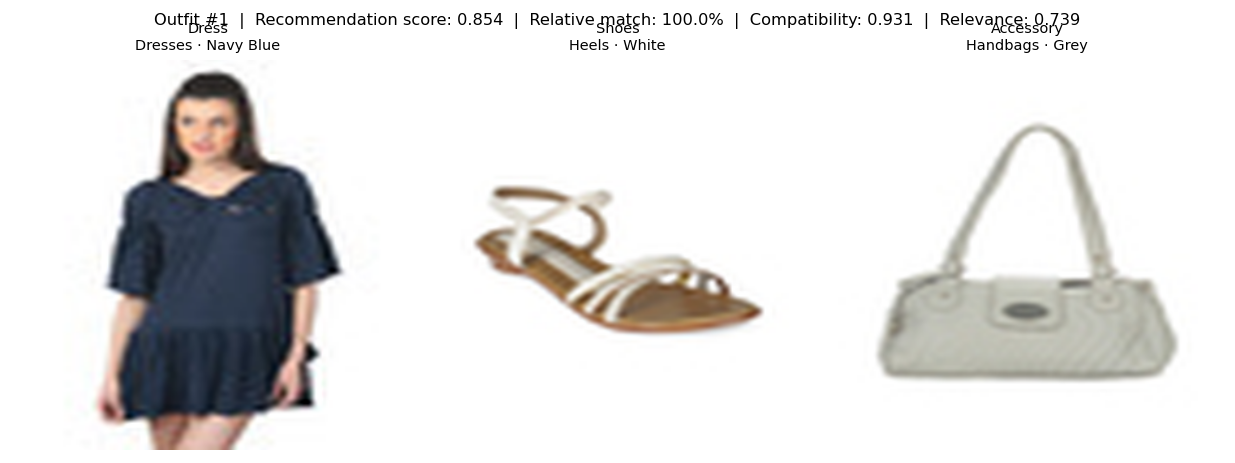

Why this outfit was recommended: Here's a combination with a relaxed energy that works for everyday wear. The navy blue dresses do the heavy lifting as a single piece, bringing a quietly confident, polished tone. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.
Evidence:
  - Style/occasion/body-shape relevance: 0.739
  - Compatibility (catalog-adapted model): 0.931
  - Color penalty: 0.000

Outfit #2


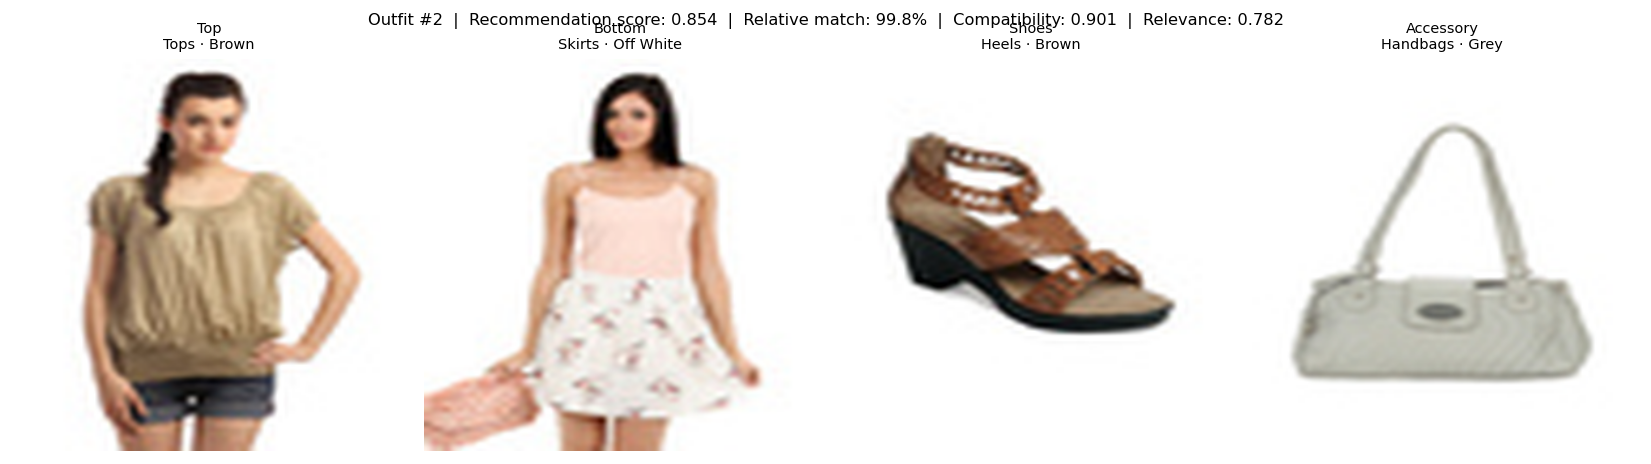

Why this outfit was recommended: Here's a combination with easy, low-key energy that suits a casual day. The brown tops set the tone up top, bringing an earthy, dependable feel. The brown heels add the final polish at ground level, bringing a warm, grounded tone. Everything here is already in your saved size (M), so fit isn't a guessing game.
Evidence:
  - Style/occasion/body-shape relevance: 0.782
  - Compatibility (catalog-adapted model): 0.901
  - Color penalty: 0.000

Outfit #3


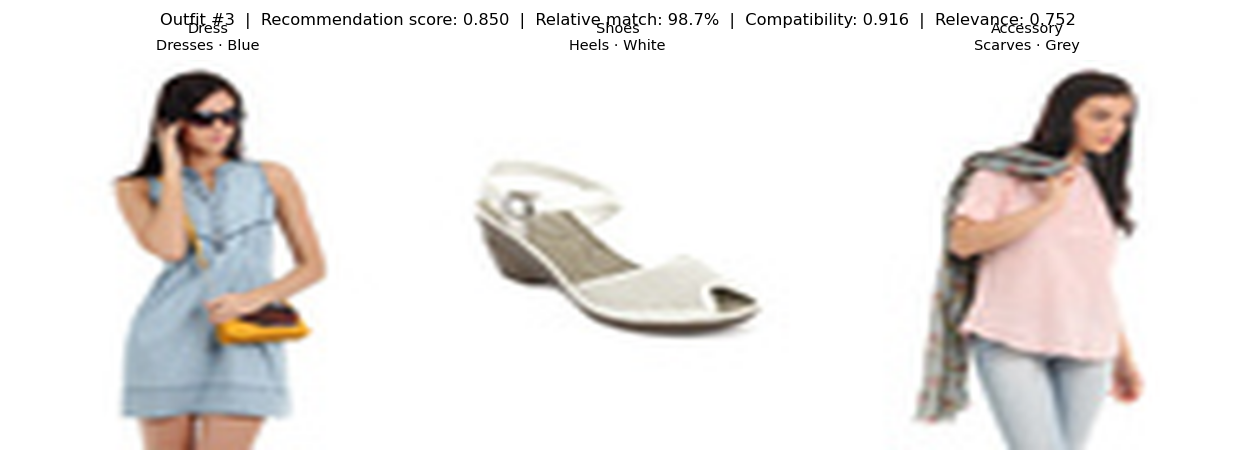

Why this outfit was recommended: This one leans into a relaxed energy that works for everyday wear. The blue dresses carry the entire look on their own, bringing a calm but confident impression. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.
Evidence:
  - Style/occasion/body-shape relevance: 0.752
  - Compatibility (catalog-adapted model): 0.916
  - Color penalty: 0.000

Outfit #4


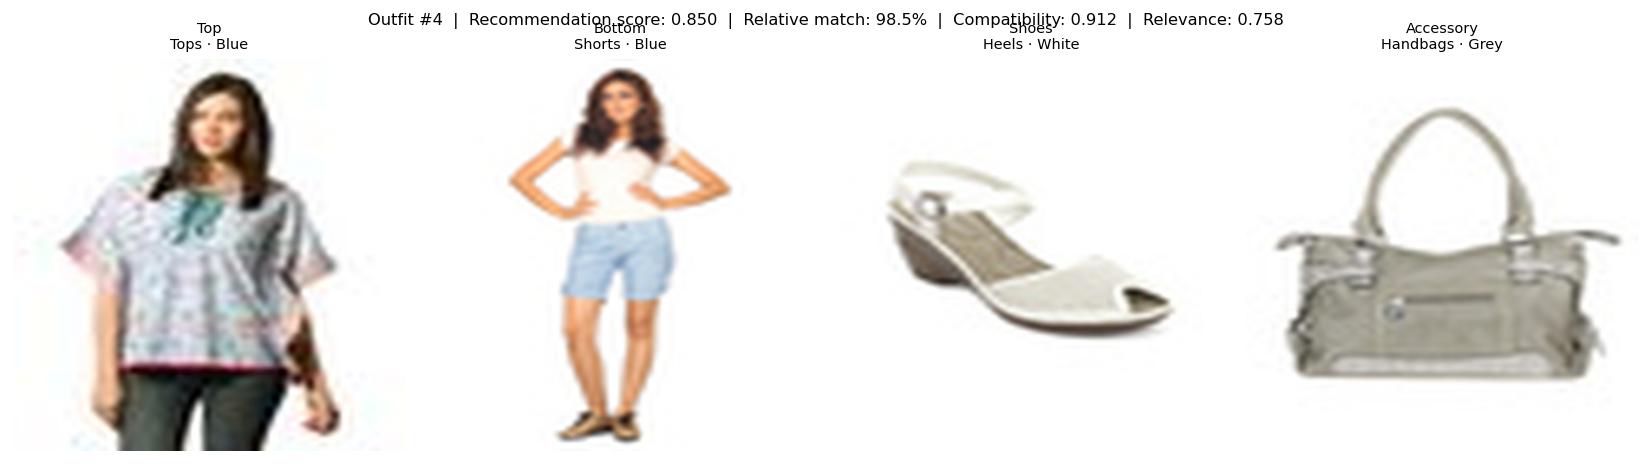

Why this outfit was recommended: This combination brings a relaxed energy that works for everyday wear. The blue tops set the tone up top, bringing a calm but confident impression. The blue shorts keep the lower half balanced, bringing a calm but confident impression. Everything here is already in your saved size (M), so fit isn't a guessing game.
Evidence:
  - Style/occasion/body-shape relevance: 0.758
  - Compatibility (catalog-adapted model): 0.912
  - Color penalty: 0.000

Outfit #5


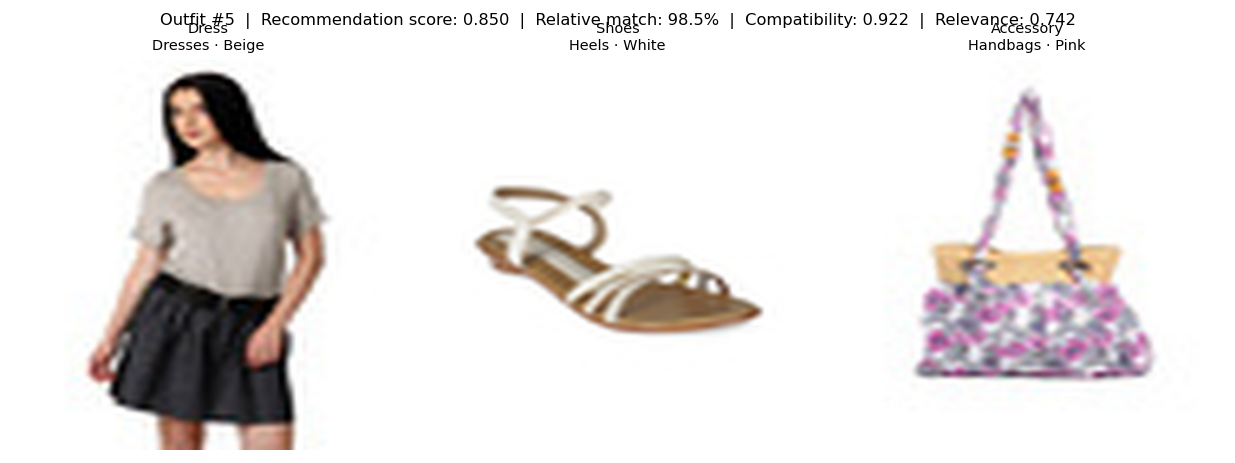

Why this outfit was recommended: This one leans into easy, low-key energy that suits a casual day. The pink handbags tie the color story together, bringing a soft, approachable tone. The beige dresses carry the entire look on their own, bringing an easy, versatile base. Everything here is already in your saved size (M), so fit isn't a guessing game.
Evidence:
  - Style/occasion/body-shape relevance: 0.742
  - Compatibility (catalog-adapted model): 0.922
  - Color penalty: 0.000


In [40]:
visual_summary = {"n_outfits": 0, "readable_images": 0, "broken_images": 0}

for rank, outfit in enumerate(diverse_outfits[:5], start=1):
    print(f"\n{'='*70}\nOutfit #{rank}")
    n_readable, n_broken = render_outfit_card(outfit, rank, save_path=f"results/outfit_{rank}.png")
    visual_summary["n_outfits"] += 1
    visual_summary["readable_images"] += n_readable
    visual_summary["broken_images"] += n_broken
    print("Why this outfit was recommended:", explain_outfit(outfit, user_profile))
    print("Evidence:")
    print(f"  - Style/occasion/body-shape relevance: {outfit['avg_relevance']:.3f}")
    print(f"  - Compatibility (catalog-adapted model): {outfit['compatibility']:.3f}")
    print(f"  - Color penalty: {outfit['color_penalty']:.3f}")


## Top-5 Comparison Grid


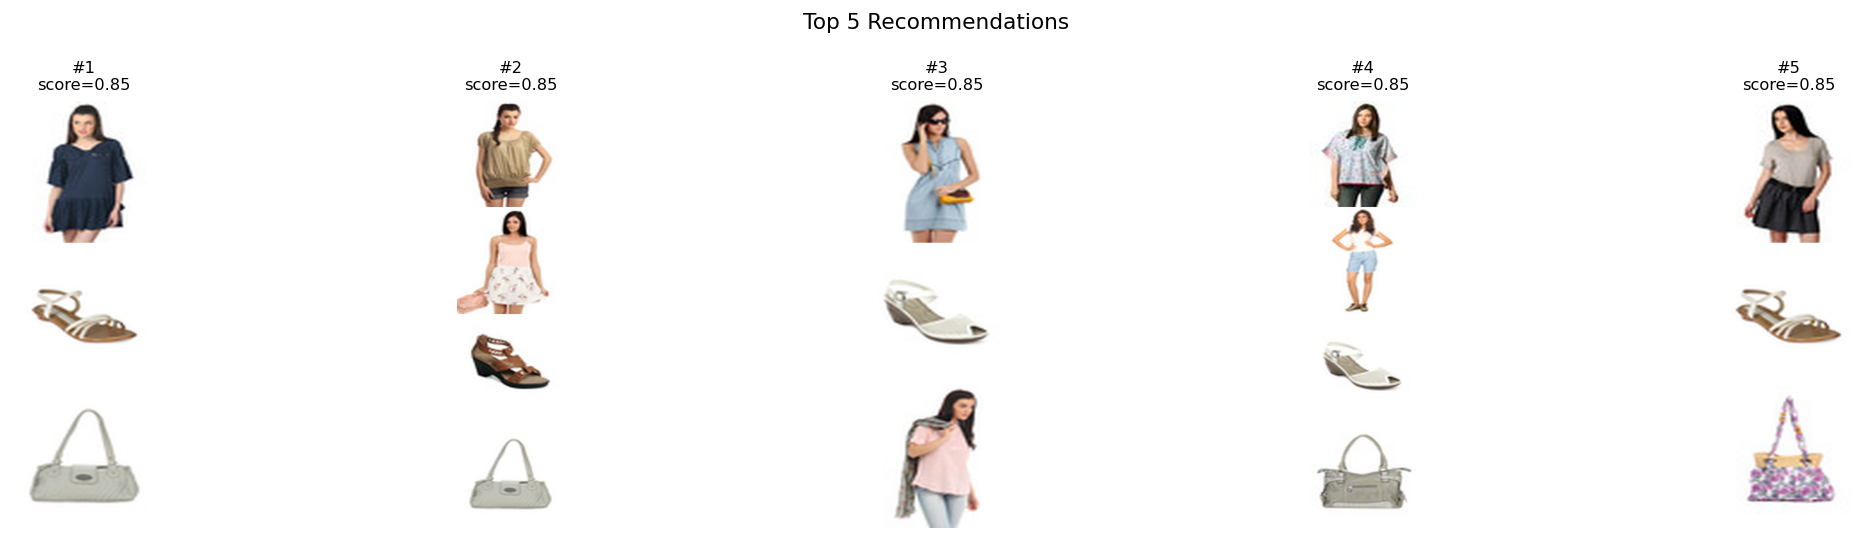

In [41]:
top5 = diverse_outfits[:5]
fig, axes = plt.subplots(1, len(top5), figsize=(3.6 * len(top5), 4.2), dpi=130)
if len(top5) == 1:
    axes = [axes]

for col, (ax, outfit) in enumerate(zip(axes, top5), start=1):
    readable, _ = check_outfit_images(outfit)
    if not readable:
        ax.text(0.5, 0.5, "No image", ha="center", va="center")
        ax.axis("off")
        continue

    thumbs = [img.resize((160, 160), Image.LANCZOS) for _, img in readable]
    collage = Image.new("RGB", (160, 160 * len(thumbs)), color=(255, 255, 255))
    for i, t in enumerate(thumbs):
        collage.paste(t, (0, i * 160))
    ax.imshow(collage)
    ax.axis("off")
    ax.set_title(f"#{col}\nscore={outfit['final_score']:.2f}", fontsize=9)

plt.suptitle("Top 5 Recommendations", fontsize=12)
plt.tight_layout()
plt.savefig("results/top5_outfits.png", bbox_inches="tight")
plt.show()


##  Visual Evaluation Summary


In [42]:
print(f"Top-5 generated: {visual_summary['n_outfits']}")
print(f"Visually displayable items: {visual_summary['readable_images']}")
print(f"Missing/unreadable item images: {visual_summary['broken_images']}")
print(f"\nAverage compatibility (top-5): {np.mean([o['compatibility'] for o in diverse_outfits[:5]]):.3f}")
print(f"Average relevance (top-5):     {np.mean([o['avg_relevance'] for o in diverse_outfits[:5]]):.3f}")
print(f"Average final score (top-5):   {np.mean([o['final_score'] for o in diverse_outfits[:5]]):.3f}")
print(f"Average pairwise similarity (top-5, diversity check): {after_stats['avg_pairwise_similarity']:.3f}")


Top-5 generated: 5
Visually displayable items: 17
Missing/unreadable item images: 0

Average compatibility (top-5): 0.916
Average relevance (top-5):     0.755
Average final score (top-5):   0.852
Average pairwise similarity (top-5, diversity check): 0.506


##  Final Recommendation Demo




FINAL RECOMMENDATION DEMO
Body Shape: pear
Style:      casual
Occasion:   Casual
Season:     Summer
Size:       M

--- OUTFIT #1 ---


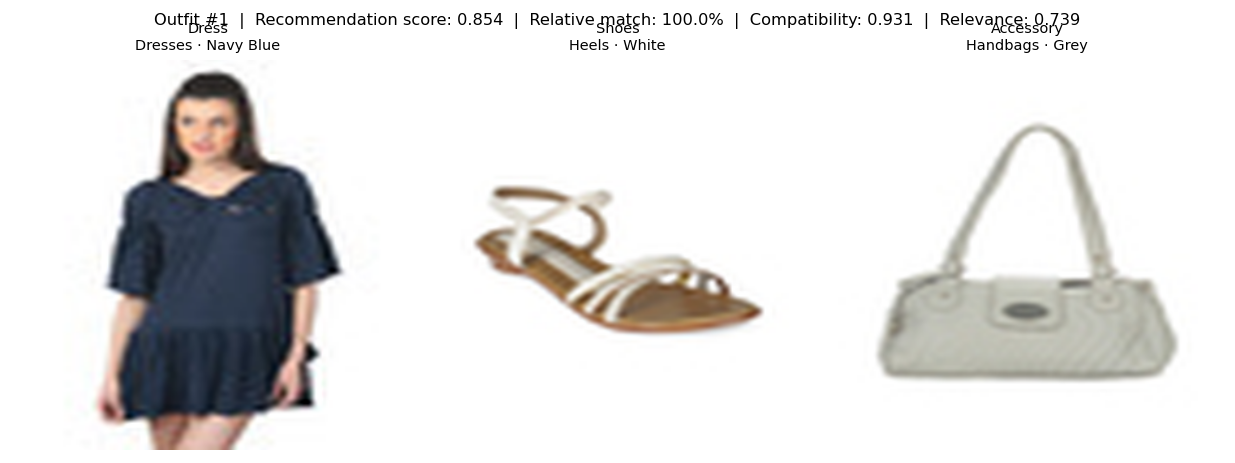

Score: 0.854 | Compatibility: 0.931 | Relevance: 0.739
Explanation: Here's a combination with a relaxed energy that works for everyday wear. The navy blue dresses do the heavy lifting as a single piece, bringing a quietly confident, polished tone. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.

--- OUTFIT #2 ---


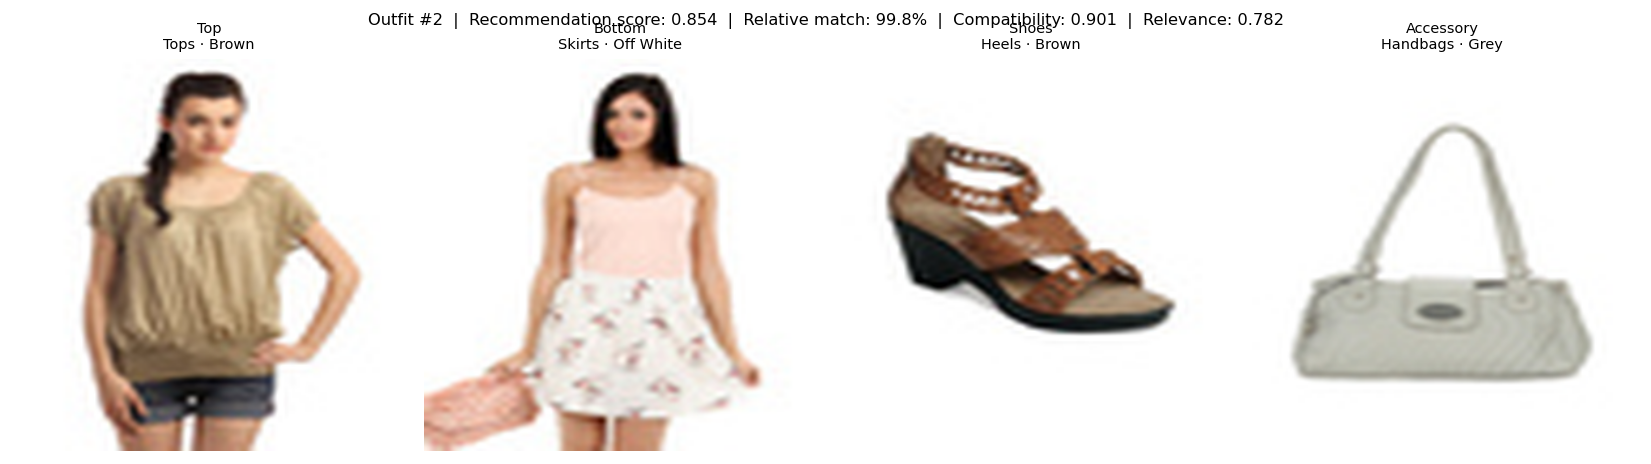

Score: 0.854 | Compatibility: 0.901 | Relevance: 0.782
Explanation: Here's a combination with easy, low-key energy that suits a casual day. The brown tops set the tone up top, bringing an earthy, dependable feel. The brown heels add the final polish at ground level, bringing a warm, grounded tone. Everything here is already in your saved size (M), so fit isn't a guessing game.

--- OUTFIT #3 ---


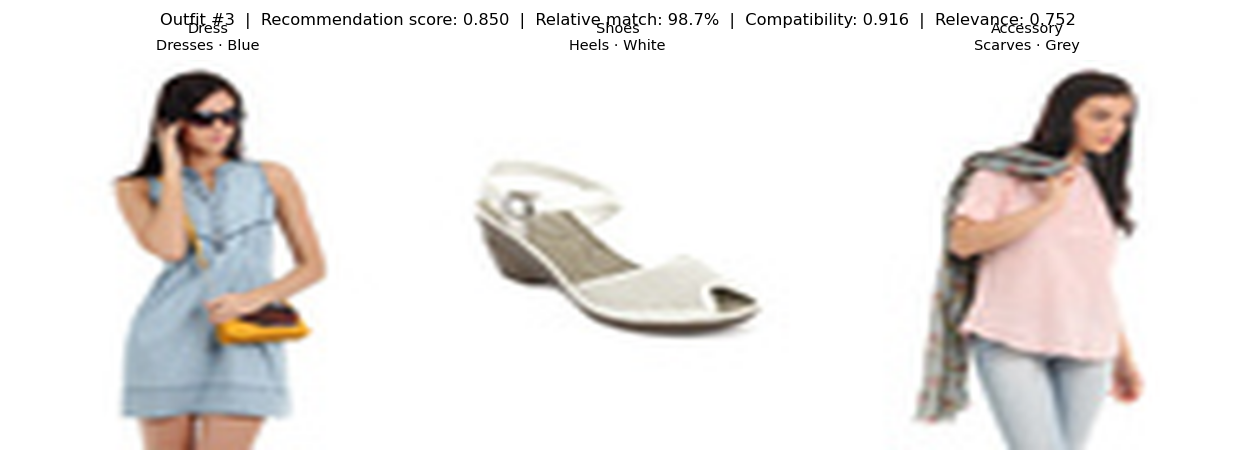

Score: 0.850 | Compatibility: 0.916 | Relevance: 0.752
Explanation: This one leans into a relaxed energy that works for everyday wear. The blue dresses carry the entire look on their own, bringing a calm but confident impression. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.

--- OUTFIT #4 ---


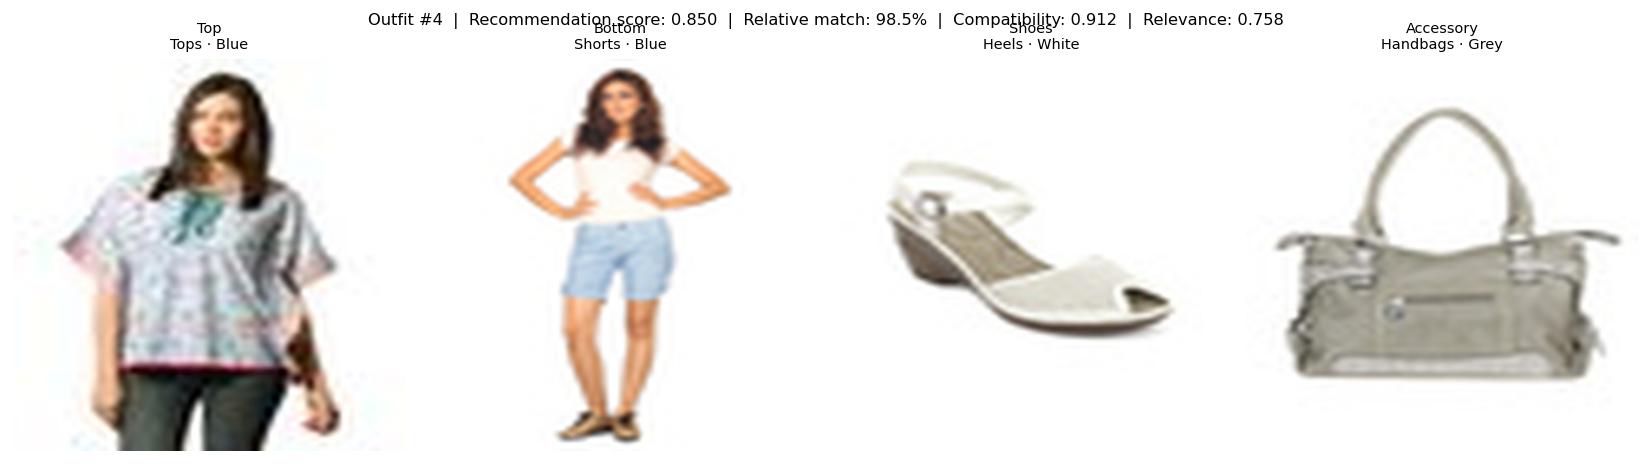

Score: 0.850 | Compatibility: 0.912 | Relevance: 0.758
Explanation: This combination brings a relaxed energy that works for everyday wear. The blue tops set the tone up top, bringing a calm but confident impression. The blue shorts keep the lower half balanced, bringing a calm but confident impression. Everything here is already in your saved size (M), so fit isn't a guessing game.

--- OUTFIT #5 ---


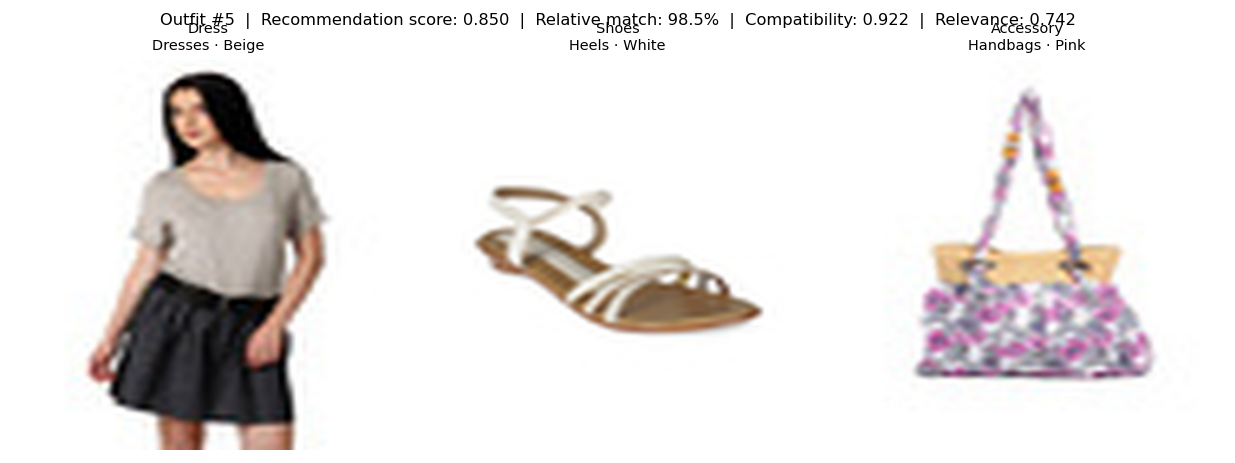

Score: 0.850 | Compatibility: 0.922 | Relevance: 0.742
Explanation: This one leans into easy, low-key energy that suits a casual day. The pink handbags tie the color story together, bringing a soft, approachable tone. The beige dresses carry the entire look on their own, bringing an easy, versatile base. Everything here is already in your saved size (M), so fit isn't a guessing game.


In [43]:
print("=" * 70)
print("FINAL RECOMMENDATION DEMO")
print("=" * 70)
print(f"Body Shape: {user_profile['body_shape']}")
print(f"Style:      {user_profile['style']}")
print(f"Occasion:   {user_profile['occasion']}")
print(f"Season:     {user_profile['season']}")
print(f"Size:       {user_profile['size']}")
print("=" * 70)

for rank, outfit in enumerate(diverse_outfits[:5], start=1):
    print(f"\n--- OUTFIT #{rank} ---")
    render_outfit_card(outfit, rank)
    print(f"Score: {outfit['final_score']:.3f} | Compatibility: {outfit['compatibility']:.3f} | Relevance: {outfit['avg_relevance']:.3f}")
    print("Explanation:", explain_outfit(outfit, user_profile))


##  Ablation: Contribution of Each Component




In [44]:
def relevance_style_only(df_):
    return _minmax(df_["style_similarity"])

def relevance_style_body(df_):
    return 0.6 * _minmax(df_["style_similarity"]) + 0.4 * _minmax(df_["body_shape_score"])

def relevance_style_occasion(df_):
    return 0.6 * _minmax(df_["style_similarity"]) + 0.4 * _minmax(df_["occasion_affinity"])

def relevance_full(df_):
    return compute_relevance_score(df_, W_STYLE, W_BODY_SHAPE, W_OCCASION)


def run_ablation_variant(relevance_fn, use_compatibility, use_diversity, top_n=5):
    scored = eligible_products.copy()
    scored["relevance_score"] = relevance_fn(scored)
    pools = build_candidate_pools(scored)
    built = generate_and_score_outfits(pools) if use_compatibility else None

    if not use_compatibility:

        global W_COMPAT
        saved = W_COMPAT
        W_COMPAT = 0.0
        built = generate_and_score_outfits(pools)
        W_COMPAT = saved

    ranked = select_diverse_outfits(built, top_n=top_n) if use_diversity else built[:top_n]

    if not ranked:
        return {"avg_final_score": float("nan"), "avg_compatibility": float("nan"), "unique_items": 0}

    avg_final = float(np.mean([o["final_score"] for o in ranked]))
    avg_compat = float(np.mean([o["compatibility"] for o in ranked]))
    unique_items = len(set(i for o in ranked for i in o["items"]["id"]))
    return {"avg_final_score": avg_final, "avg_compatibility": avg_compat, "unique_items": unique_items}


ABLATION_VARIANTS = {
    "Baseline (style only, v1-style)":        (relevance_style_only, False, False),
    "+ Body shape":                            (relevance_style_body, False, False),
    "+ Occasion":                               (relevance_style_occasion, False, False),
    "+ Compatibility (full relevance)":         (relevance_full, True, False),
    "+ Diversity (full system)":                (relevance_full, True, True),
}

print(f"{'Variant':<38} {'Avg final score':<18} {'Avg compatibility':<20} {'Unique items (top-5)'}")
ablation_results = {}
for name, (fn, use_compat, use_div) in ABLATION_VARIANTS.items():
    result = run_ablation_variant(fn, use_compat, use_div)
    ablation_results[name] = result
    print(f"{name:<38} {result['avg_final_score']:<18.3f} {result['avg_compatibility']:<20.3f} {result['unique_items']}")

print(
    "\nThese are proxy/heuristic metrics computed from the system's own scores — they show the "
    "DIRECTION of each component's effect (e.g. diversity should reduce item overlap without "
    "collapsing average score), not proof of improved human satisfaction. No Precision@K, Recall@K, "
    "or NDCG is reported because no real user-preference ground truth exists for this catalog."
)


Variant                                Avg final score    Avg compatibility    Unique items (top-5)


Scoring outfits:   0%|          | 0/89856 [00:00<?, ?it/s]

Baseline (style only, v1-style)        0.343              0.853                8


Scoring outfits:   0%|          | 0/89856 [00:00<?, ?it/s]

+ Body shape                           0.319              0.846                8


...

+ Occasion                             0.348              0.821                8


Scoring outfits:   0%|          | 0/89856 [00:00<?, ?it/s]

+ Compatibility (full relevance)       0.853              0.913                8


Scoring outfits:   0%|          | 0/89856 [00:00<?, ?it/s]

Item reuse check across the 5 selected outfits: most-reused single item appears 2x (cap was 2).
+ Diversity (full system)              0.852              0.916                14

These are proxy/heuristic metrics computed from the system's own scores — they show the DIRECTION of each component's effect (e.g. diversity should reduce item overlap without collapsing average score), not proof of improved human satisfaction. No Precision@K, Recall@K, or NDCG is reported because no real user-preference ground truth exists for this catalog.


## Output JSON (for the website / virtual try-on model)


In [45]:
def build_output_package(outfits_to_include, user, all_outfits_for_normalization, top_n=5):
    package = {
        "user_input": user,
        "attribute_provenance": ATTRIBUTE_PROVENANCE,
        "outfits": [],
    }
    for i, outfit in enumerate(outfits_to_include[:top_n]):
        package["outfits"].append({
            "outfit_id": f"outfit_{i+1}",
            "type": outfit["type"],
            "relative_match_score": relative_match_score(outfit, all_outfits_for_normalization),
            "recommendation_score": round(outfit["final_score"], 4),
            "explanation": explain_outfit(outfit, user),
            "component_scores": {
                "compatibility": round(outfit["compatibility"], 4),
                "avg_relevance": round(outfit["avg_relevance"], 4),
            },
            "items": [
                {
                    "product_id": str(item["id"]),
                    "category": item["garment_category"],
                    "article_type": item["articleType"],
                    "color": item["baseColour"],
                    "name": item["productDisplayName"],
                    "image_ref": f"product_{item['id']}.jpg",
                }
                for _, item in outfit["items"].iterrows()
            ],
        })
    return package

output_package = build_output_package(diverse_outfits, user_profile, outfits, top_n=5)

with open("recommendation_output.json", "w") as f:
    json.dump(output_package, f, indent=2)

print(json.dumps(output_package["outfits"][0], indent=2))


{
  "outfit_id": "outfit_1",
  "type": "Dress+Shoes+Accessory",
  "relative_match_score": 100.0,
  "recommendation_score": 0.8541,
  "explanation": "Here's a combination with a relaxed energy that works for everyday wear. The navy blue dresses do the heavy lifting as a single piece, bringing a quietly confident, polished tone. The white heels give the outfit a chic, energetic finish, bringing a crisp, put-together look. Everything here is already in your saved size (M), so fit isn't a guessing game.",
  "component_scores": {
    "compatibility": 0.9309,
    "avg_relevance": 0.7389
  },
  "items": [
    {
      "product_id": "40431",
      "category": "Dress",
      "article_type": "Dresses",
      "color": "Navy Blue",
      "name": "Tonga Women Navy Blue Dress",
      "image_ref": "product_40431.jpg"
    },
    {
      "product_id": "46584",
      "category": "Shoes",
      "article_type": "Heels",
      "color": "White",
      "name": "Catwalk Women White Sandals",
      "image_ref":

## Reproducibility: Experiment Configuration


In [46]:
EXPERIMENT_CONFIG = {
    "random_seed": CONFIG["random_seed"],
    "fashionclip_model": "hf-hub:Marqo/marqo-fashionCLIP",
    "embedding_dim": int(EMBED_DIM),
    "catalog_size_after_cleaning": len(df),
    "eligible_products_this_run": len(eligible_products),
    "compat_products_train_val_test": [len(products_train), len(products_val), len(products_test)],
    "compat_pairs_train_val_test": [len(train_pairs), len(val_pairs), len(test_pairs)],
    "small_catalog_fallback_active": SMALL_CATALOG_FALLBACK_ACTIVE,
    "compatibility_net_architecture": (
        f"dual-path: visual branch ([|A-B|,A*B] {EMBED_DIM*2}->128->32) + "
        f"metadata branch (dim={META_DIM}->{max(8, META_DIM // 2)}), fused (concat)->16->1"
    ) if not SMALL_CATALOG_FALLBACK_ACTIVE else "N/A (fallback mode)",
    "optimizer": "Adam" if not SMALL_CATALOG_FALLBACK_ACTIVE else "N/A",
    "learning_rate": 1e-3 if not SMALL_CATALOG_FALLBACK_ACTIVE else "N/A",
    "weight_decay": CONFIG["compat_weight_decay"],
    "max_epochs": CONFIG["compat_epochs"],
    "early_stopping_patience": CONFIG["compat_patience"],
    "epochs_actually_run": len(history["train_loss"]),
    "relevance_weights": CONFIG["relevance_weights"],
    "outfit_score_weights": CONFIG["outfit_score_weights"],
    "color_penalty_weight": CONFIG["color_penalty_weight"],
    "selected_diversity_threshold": CONFIG["diversity_threshold"],
    "test_metrics": test_metrics,
}

print(json.dumps(EXPERIMENT_CONFIG, indent=2, default=str))

with open("results/experiment_config.json", "w") as f:
    json.dump(EXPERIMENT_CONFIG, f, indent=2, default=str)


{
  "random_seed": 42,
  "fashionclip_model": "hf-hub:Marqo/marqo-fashionCLIP",
  "embedding_dim": 512,
  "catalog_size_after_cleaning": 44072,
  "eligible_products_this_run": 4762,
  "compat_products_train_val_test": [
    8059,
    1726,
    1728
  ],
  "compat_pairs_train_val_test": [
    948,
    237,
    237
  ],
  "small_catalog_fallback_active": false,
  "compatibility_net_architecture": "dual-path: visual branch ([|A-B|,A*B] 1024->128->32) + metadata branch (dim=7->8), fused (concat)->16->1",
  "optimizer": "Adam",
  "learning_rate": 0.001,
  "weight_decay": 0.0003,
  "max_epochs": 120,
  "early_stopping_patience": 12,
  "epochs_actually_run": 39,
  "relevance_weights": {
    "style": 0.3333333333333333,
    "body_shape": 0.3333333333333333,
    "occasion": 0.3333333333333333
  },
  "outfit_score_weights": {
    "compatibility": 0.6,
    "relevance": 0.4
  },
  "color_penalty_weight": 0.1,
  "selected_diversity_threshold": 0.85,
  "test_metrics": {
    "available": true,
    "n

## Save Outputs

In [47]:
torch.save(product_embeddings, "fashionclip_blended_embeddings.pt")
if compat_model is not None:
    torch.save(compat_model.state_dict(), "compatibility_model.pt")
else:
    print("No CompatibilityNet weights to save — small-catalog fallback mode was active this run.")

if '_image_loader' in catalog.columns:
    catalog = catalog.drop(columns=['_image_loader'])
if '_image_loader' in eligible_products.columns:
    eligible_products = eligible_products.drop(columns=['_image_loader'])

for outfit in outfits:
    if isinstance(outfit.get('items'), pd.DataFrame):
        if '_image_loader' in outfit['items'].columns:
            outfit['items'] = outfit['items'].drop(columns=['_image_loader'])

# Multi-profile fix: save the FULL catalog under this filename.
catalog.to_pickle("eligible_products.pkl")
embedding_index.to_pickle("embedding_index.pkl")

with open("recommended_outfits.pkl", "wb") as f:
    pickle.dump(outfits, f)

print("Saved.")

Saved.


## Fast, Multi-Profile, Ensemble-Powered Recommendation Engine (the actual entry point)

Everything above runs once, top-to-bottom, for a single hardcoded demo
profile (`user_profile = get_sample_user(0)`) - that's by design, since it's
also what produces the Phase 1 report numbers, and nothing above was
touched to change that in a way that breaks it.

The function below is different: it takes **any** user profile as an
argument and can be called **repeatedly, for different profiles, without
re-running the notebook**. Three things now feed into it that didn't
before:

1. **Ensemble scoring**: `learned_compatibility_by_id()` (defined in the
   CompatibilityNet training cell, above) now blends CompatibilityNet with
   the separately trained linear model, using the validation-tuned weight
   from the Ensemble section - the same `0.932`-accuracy signal from the
   ablation table, not just CompatibilityNet alone. Every scoring path in
   this notebook (exhaustive generation, beam search, diversity re-ranking)
   goes through this one function, so this single change upgrades all of
   them at once. Controlled by `CONFIG["use_ensemble"]`.
2. **Compatibility-led weighting + a quality floor**: `CONFIG["outfit_score_weights"]`
   is now compatibility-led (0.6 / 0.4) instead of equal, and
   `CONFIG["min_compat_floor"]` drops any outfit whose *weakest* pairwise
   link (not just its average) falls below a threshold - so one badly-
   clashing pair can't hide behind three good ones.
3. **Beam search**: only the best `beam_width` partial outfits are kept at
   each category step (using the exact same `score_outfit()` used above),
   instead of the full Cartesian-product enumeration - the part that made
   this slow to call on every website request.

### Keeping this accurate as your catalog changes

CompatibilityNet, the ensemble's linear model, and the catalog-wide
embeddings are all trained/computed from `catalog` (the full cleaned
catalog, after the multi-profile fix above) - not a fixed snapshot baked
into this file. When your merchant catalog changes meaningfully (new
products added, categories shift), **re-run this notebook top-to-bottom
once** so `catalog`, the embeddings, CompatibilityNet, and the ensemble's
linear model all retrain on the current data - then `recommend_outfits()`
keeps serving requests using the refreshed models. This notebook does not
auto-detect catalog changes or retrain on a schedule; that scheduling
(e.g. a nightly job) is something to add on the deployment side, calling
this notebook (or a script extracted from it) as the retraining step.


In [48]:
def recommend_outfits(user_profile, top_n=5, beam_width=30):
    """Fast, multi-profile recommendation entry point.

    user_profile example:
        {"size": "M", "body_shape": "pear", "occasion": "Casual",
         "season": "Summer", "style": "casual"}

    Returns a JSON-serializable dict: {"user_input": ..., "outfits": [...]}
    """
    # --- 1. Filter (same filter_products() defined above) ---
    elig = filter_products(catalog, user_profile)
    if len(elig) == 0:
        raise ValueError("No products match this user's size/season/occasion filter.")

    # --- 2. Request-scoped embedding subset (same pattern as the fix above) ---
    elig_emb = torch.stack([get_embedding(pid) for pid in elig["id"]])
    elig_img_emb = torch.stack([get_image_embedding(pid) for pid in elig["id"]])

    # --- 3. Relevance scoring (reusing the exact functions defined above) ---
    user_text = f"A {user_profile['style']} {user_profile['season'].lower()} outfit"
    text_tokens = tokenizer([user_text]).to(device)
    with torch.no_grad():
        user_embedding = model.encode_text(text_tokens, normalize=True).cpu()

    elig = elig.copy()
    elig["style_similarity"] = (elig_emb @ user_embedding.T).squeeze(1).numpy()
    elig["body_shape_score"] = body_shape_scores(elig_img_emb, user_profile["body_shape"])
    elig["occasion_affinity"] = occasion_affinity_scores(elig_emb, user_profile["occasion"])
    elig["relevance_score"] = compute_relevance_score(elig, W_STYLE, W_BODY_SHAPE, W_OCCASION)

    # --- 4. Candidate pools (same build_candidate_pools(), already fixed to use df_'s own categories) ---
    pools = build_candidate_pools(elig, top_k=TOP_K)

    # --- 5. Beam search: same score_outfit()/build_base_outfits() logic as the exhaustive
    #        run above, just pruned to `beam_width` at every step instead of kept in full ---
    bases = build_base_outfits(pools)
    beams = []
    for b in bases:
        items_df = pd.DataFrame(b["items"])
        outfit = {"type": b["type"], "items": items_df}
        outfit.update(score_outfit(items_df))
        beams.append(outfit)
    beams.sort(key=lambda o: o["final_score"], reverse=True)
    beams = beams[:beam_width]

    for cat in ALWAYS_ATTACH_CATEGORIES:
        pool = pools.get(cat)
        if pool is None or len(pool) == 0:
            continue
        extensions = []
        for beam in beams:
            for _, extra in pool.head(OPTIONAL_SLOT_K).iterrows():
                new_items = pd.concat([beam["items"], extra.to_frame().T], ignore_index=True)
                new_outfit = {"type": beam["type"] + f"+{cat}", "items": new_items}
                new_outfit.update(score_outfit(new_items))
                extensions.append(new_outfit)
        extensions.sort(key=lambda o: o["final_score"], reverse=True)
        beams = extensions[:beam_width]

    for cat in CONDITIONAL_CATEGORIES:
        pool = pools.get(cat)
        if pool is None or len(pool) == 0:
            continue
        extensions = []
        for beam in beams:
            extensions.append(beam)  # keep the without-layering version too
            for _, extra in pool.head(OPTIONAL_SLOT_K).iterrows():
                new_items = pd.concat([beam["items"], extra.to_frame().T], ignore_index=True)
                new_outfit = {"type": beam["type"] + f"+{cat}", "items": new_items}
                new_outfit.update(score_outfit(new_items))
                extensions.append(new_outfit)
        extensions.sort(key=lambda o: o["final_score"], reverse=True)
        beams = extensions[:beam_width]

    beams.sort(key=lambda o: o["final_score"], reverse=True)

    # --- 6. Quality floor: drop any outfit whose WEAKEST pairwise link falls
    #        below CONFIG["min_compat_floor"] - an outfit can have a decent
    #        AVERAGE compatibility while still containing one badly-clashing
    #        pair; this catches that case instead of only looking at the mean.
    floor = CONFIG.get("min_compat_floor", 0.0)
    quality_beams = [b for b in beams if b.get("learned_compat_min", 1.0) >= floor]
    if len(quality_beams) < top_n:
        # Relax rather than fail outright - a request-time floor should never
        # produce zero results, just warn that the floor couldn't be fully honored.
        print(f"Note: only {len(quality_beams)} outfits cleared the compatibility floor "
              f"({floor}); backfilling with the next-best outfits below that floor.")
        seen_ids = {id(b) for b in quality_beams}
        backfill = [b for b in beams if id(b) not in seen_ids]
        quality_beams = quality_beams + backfill
    beams = quality_beams

    # --- 7. Diversity re-ranking (reusing select_diverse_outfits() as-is, already includes the max-item-reuse cap) ---
    finalists = select_diverse_outfits(beams, top_n=top_n)

    # --- 7. Explanations (calling explain_outfit_structured() directly - NOT the id()-based
    #        `explain_outfit` closure above, which only works for the one global demo run) ---
    explanations, angles_used = [], []
    for rank, outfit in enumerate(finalists, start=1):
        result, angle = explain_outfit_structured(outfit, user_profile, rank, list(angles_used))
        angles_used.append(angle)
        explanations.append(result)

    # --- 8. Output package (local version - same shape as build_output_package() above) ---
    package = {"user_input": user_profile, "outfits": []}
    for i, (outfit, explanation) in enumerate(zip(finalists, explanations)):
        package["outfits"].append({
            "outfit_id": f"outfit_{i+1}",
            "type": outfit["type"],
            "relative_match_score": relative_match_score(outfit, beams),
            "recommendation_score": round(outfit["final_score"], 4),
            "explanation": explanation,
            "component_scores": {
                "compatibility": round(outfit["compatibility"], 4),
                "avg_relevance": round(outfit["avg_relevance"], 4),
            },
            "items": [
                {
                    "product_id": str(item["id"]),
                    "category": item["garment_category"],
                    "article_type": item["articleType"],
                    "color": item["baseColour"],
                    "name": item["productDisplayName"],
                }
                for _, item in outfit["items"].iterrows()
            ],
        })
    return package

### Try it with a few different profiles

In [49]:
for profile in SAMPLE_USERS[:3]:
    result = recommend_outfits(profile, top_n=5)
    print(f"\n=== {profile} ===")
    for o in result["outfits"]:
        print(f"  {o['outfit_id']}: score={o['recommendation_score']} match={o['relative_match_score']}% type={o['type']}")

Note: only found 3/5 outfits satisfying both the similarity threshold (0.85) and the max-item-reuse cap (2). Consider raising optional_slot_k further or relaxing max_item_reuse if this run is catalog-limited.
Item reuse check across the 3 selected outfits: most-reused single item appears 2x (cap was 2).

=== {'size': 'M', 'body_shape': 'pear', 'occasion': 'Casual', 'season': 'Summer', 'style': 'casual'} ===
  outfit_1: score=0.8536 match=100.0% type=Top+Bottom+Shoes+Accessory
  outfit_2: score=0.8501 match=48.8% type=Top+Bottom+Shoes+Accessory
  outfit_3: score=0.8477 match=13.4% type=Top+Bottom+Shoes+Accessory
Note: only found 1/5 outfits satisfying both the similarity threshold (0.85) and the max-item-reuse cap (2). Consider raising optional_slot_k further or relaxing max_item_reuse if this run is catalog-limited.
Item reuse check across the 1 selected outfits: most-reused single item appears 1x (cap was 2).

=== {'size': 'S', 'body_shape': 'hourglass', 'occasion': 'Formal', 'season'

## Website export (added) - run the cells below LAST, top to bottom
Produces `recommendation_index.json` for the website. Needs: `catalog_export.json` (or the export script) and your Supabase URL + service key.

In [50]:
# FitStyle export 1/6 - sync product sizes with the REAL DynamoDB catalogue
# A file-picker will open. Choose catalog_export.json from your project folder.
# (If you do not have it, choose export_catalog_for_migration.py instead - it will be run for you.)
import json, os, subprocess
from google.colab import files

up = files.upload()
if "catalog_export.json" not in up:
    if "export_catalog_for_migration.py" not in up:
        raise SystemExit("Please upload catalog_export.json (or export_catalog_for_migration.py)")
    subprocess.run(["python", "export_catalog_for_migration.py"], check=True)
_export = json.load(open("catalog_export.json"))
_export = _export if isinstance(_export, list) else _export.get("products", _export.get("items", []))

def _sizes(rec):
    raw = rec.get("available_sizes") or rec.get("size") or []
    if isinstance(raw, str):
        raw = [s.strip() for s in raw.split(",")]
    return [s.upper() for s in raw if s]

_real_sizes = {str(r["id"]): _sizes(r) for r in _export if r.get("id") is not None}
_before = catalog["available_sizes"].copy()
catalog["available_sizes"] = [_real_sizes.get(str(pid), old) for pid, old in zip(catalog["id"], _before)]
_found = sum(str(i) in _real_sizes for i in catalog["id"])
print(f"synced sizes: {_found}/{len(catalog)} products found in the DynamoDB export")


Saving export_catalog_for_migration.py to export_catalog_for_migration.py
synced sizes: 11513/11513 products found in the DynamoDB export


In [51]:
# Problems this fixes (seen in your v20 output): strict size+season+usage gave
# only 1-3 outfits for some profiles, and "Wedding"/"Interview" matched ZERO
# products because the dataset's `usage` column has no such values.
import copy

OCCASION_TO_USAGE = {
    "casual":    {"casual", "smart casual"},
    "formal":    {"formal", "smart casual"},
    "party":     {"party"},
    "interview": {"formal", "smart casual"},
    "wedding":   {"formal", "party"},
}
ANY_DRESSY_USAGE = {"casual", "smart casual", "formal", "party"}
STYLE_BY_OCCASION = {"casual": "casual", "formal": "elegant", "party": "chic",
                     "interview": "classic", "wedding": "elegant"}
_RELAX_LEVEL = 0   # 0 = strict, 1 = ignore season, 2 = ignore season + loosen usage

def filter_products(catalog_df, user):          # replaces the notebook's version
    occ = _norm(user["occasion"])
    f = catalog_df.copy()
    f = f[f["available_sizes"].apply(lambda s: user["size"] in s)]       # size ALWAYS enforced
    if _RELAX_LEVEL < 1:
        f = f[f["season"].apply(_norm) == _norm(user["season"])]
    if _RELAX_LEVEL < 2:
        f = f[f["usage"].apply(_norm).isin(OCCASION_TO_USAGE.get(occ, {occ}))]
    else:
        f = f[f["usage"].apply(_norm).isin(ANY_DRESSY_USAGE)]
    return f.reset_index(drop=True)

# capture the evidence dict (style/body/occasion fit, colour relationship...) per finalist
if "_orig_explain_structured" not in globals():
    _orig_explain_structured = explain_outfit_structured
_captured_evidence = []
def explain_outfit_structured(outfit, user, rank, prior_angles):
    try:
        ev = build_outfit_evidence(outfit, user, [outfit])
    except Exception:
        ev = {}
    _captured_evidence.append(ev)
    return _orig_explain_structured(outfit, user, rank, prior_angles)


In [52]:
def _pid_key(outfit):
    return frozenset(i["product_id"] for i in outfit["items"])

def build_profile_pools(user, per_category=30):
    """Steps 1-4 of recommend_outfits(): ranked candidates per garment category.
    Used by the UI when the shopper taps a product to see 'more dresses' etc."""
    elig = filter_products(catalog, user)
    if len(elig) == 0:
        return {}
    elig_emb = torch.stack([get_embedding(pid) for pid in elig["id"]])
    elig_img_emb = torch.stack([get_image_embedding(pid) for pid in elig["id"]])
    tokens = tokenizer([f"A {user['style']} {user['season'].lower()} outfit"]).to(device)
    with torch.no_grad():
        u = model.encode_text(tokens, normalize=True).cpu()
    elig = elig.copy()
    elig["style_similarity"] = (elig_emb @ u.T).squeeze(1).numpy()
    elig["body_shape_score"] = body_shape_scores(elig_img_emb, user["body_shape"])
    elig["occasion_affinity"] = occasion_affinity_scores(elig_emb, user["occasion"])
    elig["relevance_score"] = compute_relevance_score(elig, W_STYLE, W_BODY_SHAPE, W_OCCASION)
    pools = build_candidate_pools(elig, top_k=per_category)
    return {cat: [{"id": str(r["id"]), "rel": round(float(r["relevance_score"]), 4)}
                  for _, r in df.head(per_category).iterrows()]
            for cat, df in pools.items()}

def recommend_with_fallback(user, top_n=5):
    """Always try to return top_n outfits: strict -> ignore season -> loosen usage."""
    global _RELAX_LEVEL
    merged, seen, level_used = [], set(), 0
    for level in (0, 1, 2):
        _RELAX_LEVEL = level
        _captured_evidence.clear()
        try:
            pkg = recommend_outfits(user, top_n=top_n)
        except Exception as e:                       # empty filter / missing category pools
            continue
        for o, ev in zip(pkg["outfits"], list(_captured_evidence)):
            k = _pid_key(o)
            if k in seen:
                continue
            seen.add(k)
            o = dict(o); o["evidence"] = ev; o["level"] = level
            merged.append(o); level_used = max(level_used, level)
        if len(merged) >= top_n:
            break
    merged = merged[:top_n]
    for i, o in enumerate(merged, 1):
        o["outfit_id"] = f"outfit_{i}"
    _RELAX_LEVEL = level_used
    pools = build_profile_pools(user) if merged else {}
    _RELAX_LEVEL = 0
    return merged, level_used, pools


In [53]:
# 4 sizes x 5 body shapes x 5 occasions x 4 seasons = 400 profiles.
# Free-Colab runtime: expect ~20-40 min. Re-running resumes from the checkpoint.
import itertools, time
from tqdm.auto import tqdm

SIZES      = ["S", "M", "L", "XL"]
BODYSHAPES = ["pear", "hourglass", "apple", "rectangle", "inverted_triangle"]
OCCASIONS  = ["casual", "formal", "party", "interview", "wedding"]
SEASONS    = ["summer", "winter", "fall", "spring"]
CKPT = "/content/reco_checkpoint.json"

index = json.load(open(CKPT)) if os.path.exists(CKPT) else {}

# the LLM explanations are produced at request time by the server (Groq, free tier);
# here we only want the deterministic template, so switch the Groq key off temporarily.
_saved_key = globals().get("GROQ_API_KEY"); GROQ_API_KEY = None
_saved_env = os.environ.pop("GROQ_API_KEY", None)

combos = list(itertools.product(SIZES, BODYSHAPES, OCCASIONS, SEASONS))
for n, (size, shape, occ, season) in enumerate(tqdm(combos)):
    key = f"{size}|{shape}|{occ}|{season}"
    if key in index:
        continue
    user = {"size": size, "body_shape": shape, "occasion": occ.title(),
            "season": season.title(), "style": STYLE_BY_OCCASION[occ]}
    outfits, level, pools = recommend_with_fallback(user)
    if not outfits:
        index[key] = None
        continue
    index[key] = {
        "level": level,
        "relaxed": [] if level == 0 else (["season"] if level == 1 else ["season", "occasion"]),
        "outfits": [{
            "outfit_id": o["outfit_id"], "type": o["type"],
            "relative_match_score": round(float(o["relative_match_score"]), 1),
            "recommendation_score": o["recommendation_score"],
            "explanation": o["explanation"],            # deterministic template text
            "evidence": o["evidence"], "level": o["level"],
            "items": o["items"],
        } for o in outfits],
        "pools": pools,
    }
    if n % 20 == 0:
        json.dump(index, open(CKPT, "w"))

json.dump(index, open(CKPT, "w"))
GROQ_API_KEY = _saved_key
if _saved_env: os.environ["GROQ_API_KEY"] = _saved_env

profiles = {k: v for k, v in index.items() if v}
image_ids = sorted({it["product_id"] for p in profiles.values() for o in p["outfits"] for it in o["items"]}
                   | {c["id"] for p in profiles.values() for pool in p["pools"].values() for c in pool})
final = {"meta": {"profiles": len(profiles), "skipped": len(index) - len(profiles),
                  "image_ids": image_ids, "generated": time.strftime("%Y-%m-%d")},
         "profiles": profiles}
json.dump(final, open("/content/recommendation_index.json", "w"), separators=(",", ":"))
print(f"{len(profiles)}/{len(combos)} profiles | {len(image_ids)} products need thumbnails | "
      f"size {os.path.getsize('/content/recommendation_index.json')/1e6:.1f} MB")
print("profiles with <5 outfits:", sum(len(p["outfits"]) < 5 for p in profiles.values()))
print("profiles that needed relaxing:", sum(p["level"] > 0 for p in profiles.values()))


  0%|          | 0/400 [00:00<?, ?it/s]

Note: only found 3/5 outfits satisfying both the similarity threshold (0.85) and the max-item-reuse cap (2). Consider raising optional_slot_k further or relaxing max_item_reuse if this run is catalog-limited.
Item reuse check across the 3 selected outfits: most-reused single item appears 2x (cap was 2).
Note: only found 2/5 outfits satisfying both the similarity threshold (0.85) and the max-item-reuse cap (2). Consider raising optional_slot_k further or relaxing max_item_reuse if this run is catalog-limited.
Item reuse check across the 2 selected outfits: most-reused single item appears 2x (cap was 2).
Note: only found 2/5 outfits satisfying both the similarity threshold (0.85) and the max-item-reuse cap (2). Consider raising optional_slot_k further or relaxing max_item_reuse if this run is catalog-limited.
Item reuse check across the 2 selected outfits: most-reused single item appears 2x (cap was 2).
Note: only found 2/5 outfits satisfying both the similarity threshold (0.85) and the 

In [54]:
# The DynamoDB catalogue has empty `image` fields, so the UI would show blanks.
# Upload a small JPEG for each recommended product to the existing PUBLIC bucket
# `product-images` at catalog/<id>.jpg. The server builds that URL itself, so
# NOTHING is written to DynamoDB (no extra WCU).
# You pick your .env file; the key is only kept in this Colab session.
import io, requests
from concurrent.futures import ThreadPoolExecutor
from google.colab import files as _files

# A file-picker opens: choose the .env file from your project folder (nothing to type).
_env = {}
for _name, _data in _files.upload().items():
    for _line in _data.decode("utf-8", "ignore").splitlines():
        if "=" in _line and not _line.lstrip().startswith("#"):
            _k, _v = _line.split("=", 1)
            _env[_k.strip()] = _v.strip().strip('"').strip("'")
SB_URL = _env["SUPABASE_URL"].rstrip("/")
SB_KEY = _env["SUPABASE_SERVICE_ROLE_KEY"]
_by_id = {str(r["id"]): r for _, r in catalog.iterrows()}

def _upload(pid):
    try:
        img = load_image(_by_id[pid])
        img.thumbnail((384, 512))
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=80, optimize=True)
        r = requests.post(
            f"{SB_URL}/storage/v1/object/product-images/catalog/{pid}.jpg",
            headers={"Authorization": f"Bearer {SB_KEY}", "apikey": SB_KEY,
                     "Content-Type": "image/jpeg", "x-upsert": "true"},
            data=buf.getvalue(), timeout=60)
        return pid, r.status_code in (200, 201)
    except Exception:
        return pid, False

with ThreadPoolExecutor(8) as ex:
    results = list(tqdm(ex.map(_upload, image_ids), total=len(image_ids)))
failed = [p for p, ok in results if not ok]
print("uploaded:", len(results) - len(failed), "| failed:", len(failed), failed[:10])
# If some failed, re-run this cell (upsert is on). Then fix meta.image_ids to the successes:
ok_ids = [p for p, ok in results if ok]
final["meta"]["image_ids"] = ok_ids
json.dump(final, open("/content/recommendation_index.json", "w"), separators=(",", ":"))


Saving .env to .env


  0%|          | 0/2661 [00:00<?, ?it/s]

uploaded: 0 | failed: 2661 ['10000', '10002', '10016', '10106', '10196', '10197', '10199', '10200', '10202', '10204']


In [55]:
from google.colab import files
files.download("/content/recommendation_index.json")   # -> put in <repo>/data/recommendation_index.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>